# **DEEP LEARNING**

## Cómo funciona una red neuronal — Visión general

Una red neuronal es un sistema que aprende por ensayo y error, igual que un humano.

### La estructura

La red tiene tres partes:
- **Capa de entrada:** recibe los datos en bruto (puntuación, votos, año, duración...)
- **Capas ocultas:** transforman esos datos detectando combinaciones y patrones
- **Capa de salida:** da la respuesta final (¿buena película? sí / no)

Cada conexión entre neuronas tiene un **peso** — un número que dice cuánto importa esa conexión. Al principio son aleatorios. El entrenamiento consiste en ajustarlos hasta que la red acierte.

### Tipos de redes neuronales

El proceso de aprendizaje es universal para todas. Lo que cambia entre modelos es cómo están conectadas las capas:

- **MLP** (datos tabulares) → capas completamente conectadas, cada neurona conectada a todas las de la siguiente capa
- **CNN** (imágenes) → capas que detectan bordes, texturas, formas
- **RNN** (texto, series temporales) → capas con memoria del paso anterior
- **Transformer** (GPT, BERT) → capas con mecanismo de atención

### El proceso en 6 pasos

1. **Le das datos y la respuesta correcta** — miles de películas ya valoradas
2. **La red predice** — con los pesos que tiene en ese momento
3. **Calcula el error** — diferencia entre su predicción y la realidad
4. **Busca quién tiene la culpa** — qué pesos contribuyeron más al error
5. **Ajusta los pesos** — un poco, en la dirección correcta
6. **Repite miles de veces** — cada repetición es una época, cada época mejora

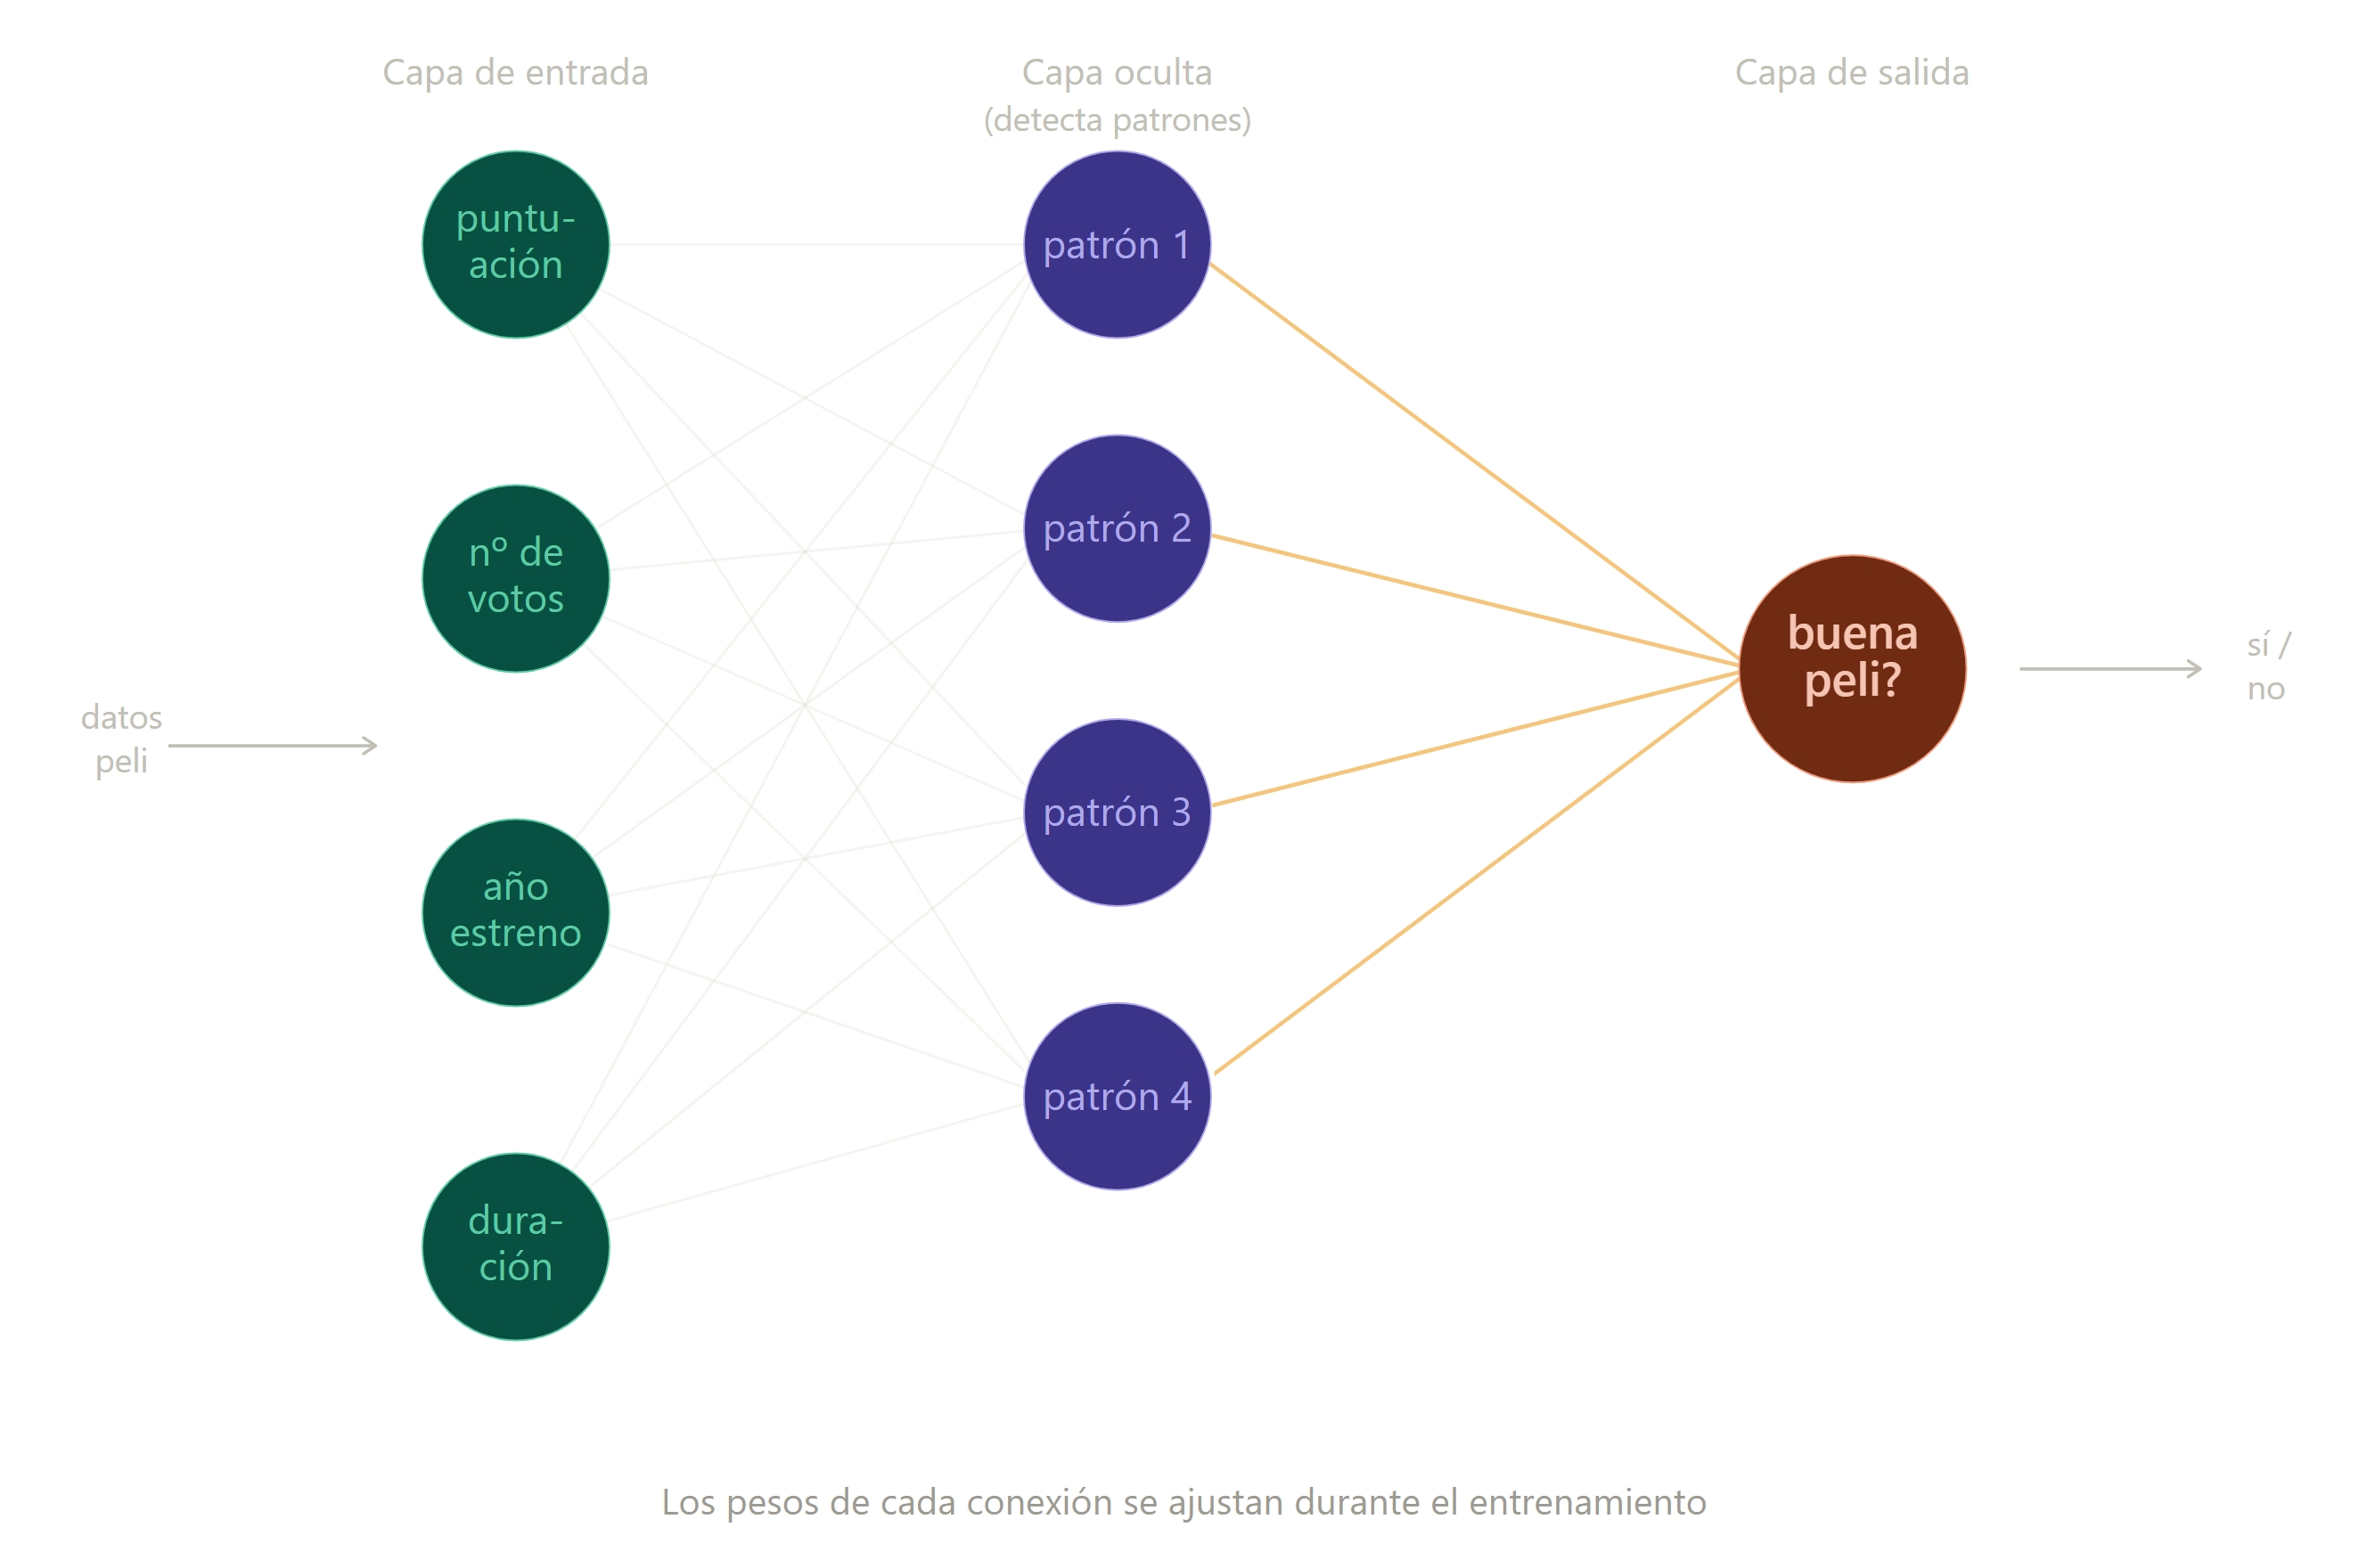

In [ ]:
from IPython.display import Image
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Model.jpeg")

## ÁRBOL DE DECISIÓN

### GENERACIÓN DEL ÁRBOL

In [ ]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

def arbol_decision_dl():
    d = Digraph(name='DL Decision Tree', format='svg')
    d.attr(rankdir='TB', size='24,40', dpi='150', fontname='Helvetica')
    d.attr('node', fontname='Helvetica', fontsize='11', margin='0.3,0.15')
    d.attr('edge', fontname='Helvetica', fontsize='10')

    def pregunta(name, label):
        d.node(name, label, shape='diamond', style='filled', fillcolor='#1a1a2e', fontcolor='white', color='#163c9f')

    def nodo(name, label):
        d.node(name, label, shape='box', style='filled,rounded', fillcolor='#163c9f', fontcolor='white')

    def hoja(name, label):
        d.node(name, label, shape='box', style='filled,rounded', fillcolor='#2d6a4f', fontcolor='white')

    def detalle(name, label):
        d.node(name, label, shape='box', style='filled', fillcolor='#f0f0f0', fontcolor='#333333')

    pregunta('Q0', '¿Qué tipo de dato tienes?')

    nodo('A', '[A] DATOS TABULARES → MLP')
    pregunta('QA', '¿Cuál es tu objetivo?')
    hoja('A1', 'Clasificación binaria\nSalida: Sigmoid\nLoss: BinaryCrossentropy')
    hoja('A2', 'Clasificación multiclase\nSalida: Softmax\nLoss: CategoricalCrossentropy')
    hoja('A3', 'Regresión\nSalida: Linear\nLoss: MSE / Huber')
    detalle('A_tip', 'Activación ocultas: ReLU\nOptimizador: Adam')
    d.edge('Q0', 'A', 'Números / Tabla')
    d.edge('A', 'QA')
    d.edge('QA', 'A1', '2 clases')
    d.edge('QA', 'A2', '>2 clases')
    d.edge('QA', 'A3', 'Predecir número')
    d.edge('A1', 'A_tip')
    d.edge('A2', 'A_tip')
    d.edge('A3', 'A_tip')

    nodo('B', '[B] IMAGEN → CNN')
    pregunta('QB', '¿Cuál es tu objetivo?')
    pregunta('QB2', '¿Cuántos datos tienes?')
    hoja('B_zs',  '<100\nZero-shot con modelo preentrenado')
    hoja('B_ft1', '100 - 1.000\nPreentrenado + fine-tuning ligero\n(ResNet, VGG)')
    hoja('B_ft2', '1.000 - 10.000\nFine-tuning completo')
    hoja('B_scr', '>10.000\nPuedes entrenar desde cero\n(preentrenados suelen ganar)')
    hoja('B_det', 'Detectar objetos\nYOLO / Faster R-CNN')
    hoja('B_gen', 'Generar imágenes\n→ ver rama [E] GAN')
    d.edge('Q0', 'B', 'Imagen')
    d.edge('B', 'QB')
    d.edge('QB', 'QB2', 'Clasificar')
    d.edge('QB2', 'B_zs',  '<100')
    d.edge('QB2', 'B_ft1', '100 - 1.000')
    d.edge('QB2', 'B_ft2', '1.000 - 10.000')
    d.edge('QB2', 'B_scr', '>10.000')
    d.edge('QB', 'B_det', 'Detectar objetos')
    d.edge('QB', 'B_gen', 'Generar')

    nodo('C', '[C] TEXTO → NLP')
    pregunta('QC', '¿Cuántos documentos tienes?')
    hoja('C_zs',  '<100 docs\nZero-shot / few-shot\nSin entrenamiento propio')
    hoja('C_ft1', '100 - 1.000 docs\nPreentrenado + fine-tuning ligero')
    hoja('C_ft2', '1.000 - 10.000 docs\nFine-tuning completo')
    hoja('C_scr', '>10.000 docs\nPuedes entrenar desde cero\n(preentrenados suelen ganar)')
    pregunta('QC2', '¿Velocidad o precisión?')
    hoja('C_vel1', 'Clasificación simple\nTF-IDF + LogReg')
    hoja('C_vel2', 'Similitud semántica\nUSE (512 dims)')
    hoja('C_vel3', 'Sentimiento rápido\nVADER (solo inglés)')
    pregunta('QC3', '¿Qué tarea NLP necesitas?')
    hoja('C_sent',  'SENTIMIENTO\nnlptown (1-5 estrellas)\nDistilBERT (binario)\nTwitter-RoBERTa (tweets)')
    hoja('C_ner',   'ENTIDADES (NER)\ndslim/bert-base-NER')
    hoja('C_topic', 'TOPICS sin etiquetas\nBERTopic\n(BERT + HDBSCAN + TF-IDF)')
    hoja('C_sum',   'RESUMIR\nDistilBART')
    hoja('C_tra',   'TRADUCIR\nMarianMT\nHelsinki-NLP/opus-mt')
    hoja('C_sim',   'SIMILITUD entre frases\nBERT embeddings CLS\n+ cosine similarity')
    pregunta('QC4', '¿Qué variante de BERT?')
    hoja('CB1', 'CPU / velocidad\n→ DistilBERT')
    hoja('CB2', 'Varios idiomas\n→ mBERT / XLM-RoBERTa')
    hoja('CB3', 'Máxima precisión\n→ RoBERTa-large')
    hoja('CB4', 'Dominio específico\nMedicina → BioBERT\nLegal → LegalBERT\nGeneral → bert-base-uncased')
    d.edge('Q0', 'C', 'Texto')
    d.edge('C', 'QC')
    d.edge('QC', 'C_zs',  '<100 docs')
    d.edge('QC', 'C_ft1', '100 - 1.000 docs')
    d.edge('QC', 'C_ft2', '1.000 - 10.000 docs')
    d.edge('QC', 'C_scr', '>10.000 docs')
    d.edge('C_ft1', 'QC2')
    d.edge('C_ft2', 'QC2')
    d.edge('C_scr', 'QC2')
    d.edge('QC2', 'C_vel1', 'Velocidad')
    d.edge('QC2', 'C_vel2', 'Velocidad')
    d.edge('QC2', 'C_vel3', 'Velocidad')
    d.edge('QC2', 'QC3', 'Precisión → BERT')
    d.edge('QC3', 'C_sent',  'Sentimiento')
    d.edge('QC3', 'C_ner',   'Entidades')
    d.edge('QC3', 'C_topic', 'Temas')
    d.edge('QC3', 'C_sum',   'Resumir')
    d.edge('QC3', 'C_tra',   'Traducir')
    d.edge('QC3', 'C_sim',   'Similitud')
    d.edge('QC3', 'QC4',     '¿Variante BERT?')
    d.edge('QC4', 'CB1')
    d.edge('QC4', 'CB2')
    d.edge('QC4', 'CB3')
    d.edge('QC4', 'CB4')

    nodo('D', '[D] SECUENCIA TEMPORAL\n→ RNN / LSTM / GRU')
    pregunta('QD', '¿Cuál es tu objetivo?')
    hoja('D1', 'Clasificar secuencia\nCorta → SimpleRNN\nLarga + precisión → LSTM\nLarga + velocidad → GRU')
    hoja('D2', 'Predecir siguiente valor\n(serie temporal, precio)\nLSTM o GRU + salida Linear')
    detalle('D_tip', '⚠ Para texto puro BERT supera a LSTM desde 2018\nUsa LSTM solo si el orden temporal\nes el núcleo del problema\n(audio, sensores, bolsa, voz)')
    d.edge('Q0', 'D', 'Secuencia temporal')
    d.edge('D', 'QD')
    d.edge('QD', 'D1', 'Clasificar')
    d.edge('QD', 'D2', 'Predecir')
    d.edge('D1', 'D_tip')
    d.edge('D2', 'D_tip')

    nodo('E', '[E] GENERAR / COMPRIMIR\n→ GAN / Autoencoder')
    pregunta('QE', '¿Qué quieres hacer?')
    hoja('E1', 'Generar datos nuevos\n(imágenes, voz, sintéticos)\n→ GAN\nGenerador vs Discriminador\n⚠ Igualar learning rates de ambos')
    hoja('E2', 'Detectar anomalías\n→ Autoencoder\nLo que no se reconstruye bien = anomalía')
    hoja('E3', 'Reducir dimensiones\n→ Autoencoder / PCA / UMAP')
    d.edge('Q0', 'E', 'Generar / comprimir')
    d.edge('E', 'QE')
    d.edge('QE', 'E1', 'Generar datos nuevos')
    d.edge('QE', 'E2', 'Detectar anomalías')
    d.edge('QE', 'E3', 'Reducir dimensiones')

    return d


### ÁRBOL

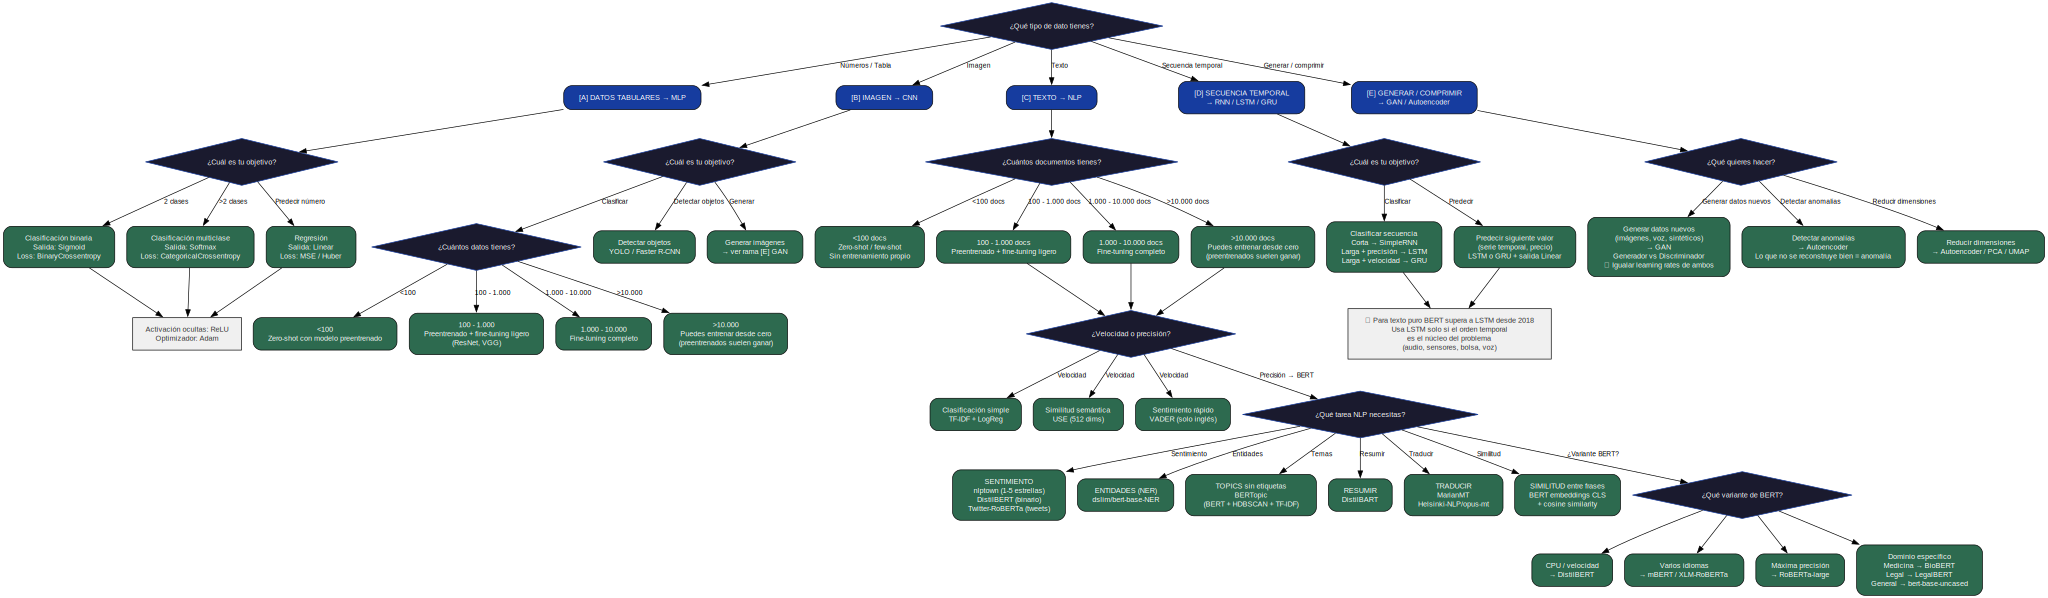

In [ ]:
from IPython.display import SVG
SVG(filename=r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\arbol_decision.svg")

# **MLP — Multilayer Perceptron (Perceptrón Multicapa)**

## Deep_Learning_Train_001 — La estructura de la red

**Resumida:** Muestra los dos inputs (X1, X2), dos neuronas ocultas con sus pesos y una neurona de salida. También aparece la tabla con el dato de entrenamiento: X1=20, X2=3, y=1.

**Detallada:** Es una red dibujada a mano con números concretos. 
- Dos datos entran (X1, X2). Cada uno se conecta a las dos neuronas ocultas con pesos distintos: w11=0.2, w21=-0.3, w12=0.4, w22=0.1. 
- Esos pesos dicen cuánto importa cada input para cada neurona. 
- La salida recibe los resultados de ambas neuronas ocultas con pesos v1=0.5 y v2=-0.6. 

Abajo a la derecha aparece la tabla con el ejemplo de entrenamiento: el modelo va a recibir X1=20, X2=3, y tiene que predecir algo cercano a y=1.

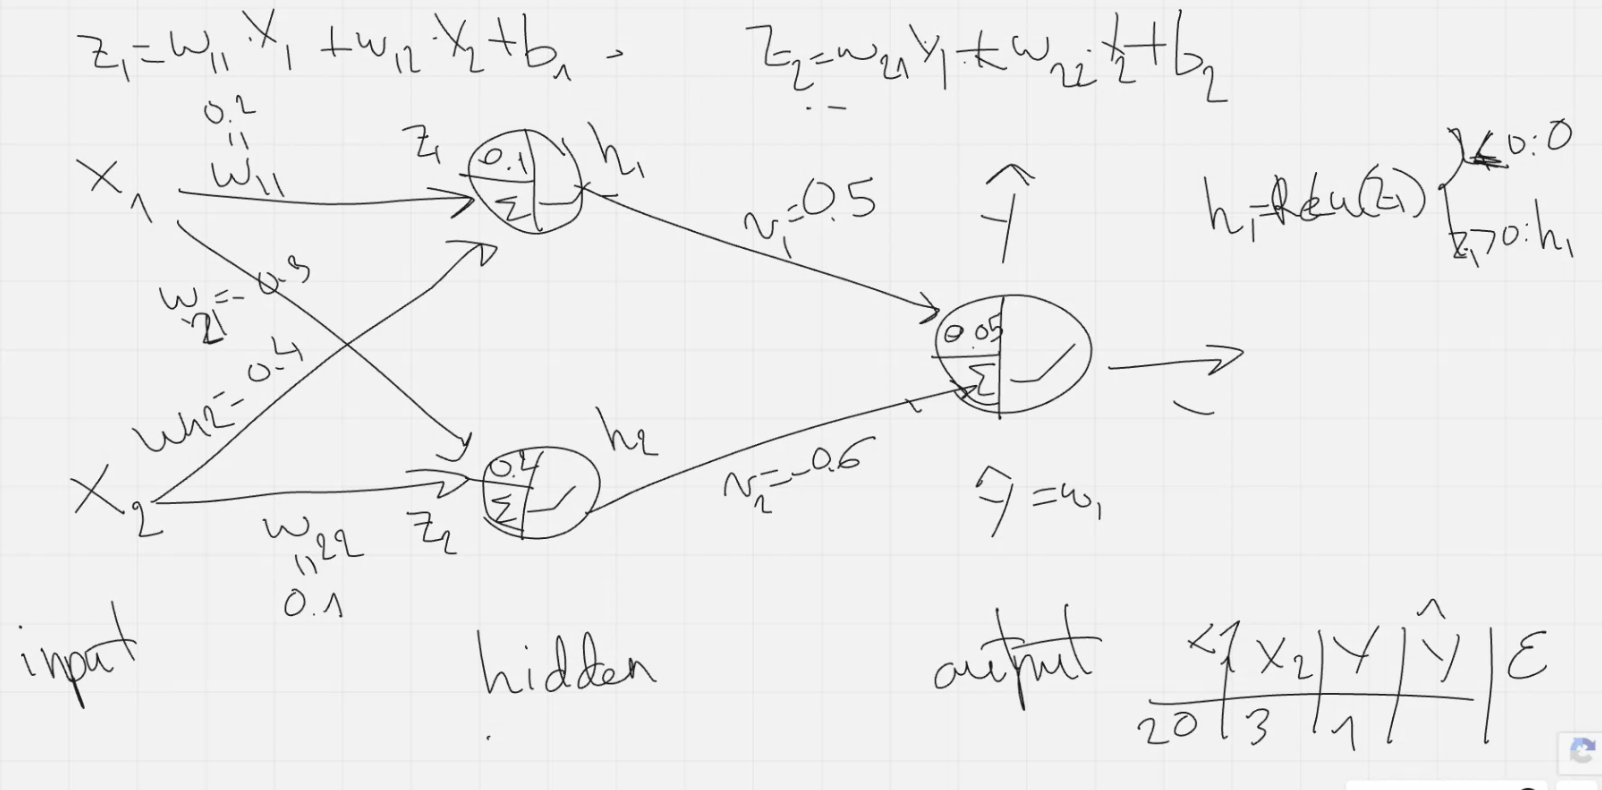

In [8]:
from IPython.display import Image
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_001.png")

## Deep_Learning_Train_002 — Forward pass y cálculo del error

**Resumida:** Neurona 1 da h1=5.3, neurona 2 queda apagada h2=0, la salida predice ŷ=2.7. El error es ε=1.445.

**Detallada:** 
- Neurona oculta 1 hace la suma: 0.2×20 + 0.4×3 + 0.1 = 5.3. ReLU lo deja pasar tal cual porque es positivo: h1=5.3. 
- Neurona oculta 2: -0.3×20 + 0.1×3 + 0.2 = -5.3. ReLU lo mata porque es negativo: h2=0. Esta neurona no aporta nada a la predicción final. 
- La capa de salida combina ambas: 5.3×0.5 + 0×(-0.6) + 0.65 = 2.7. 

El modelo predijo 2.7 pero la respuesta real era 1. El error se calcula como ε = ½×(1-2.7)² = 1.445. Error grande — hay que ajustar.

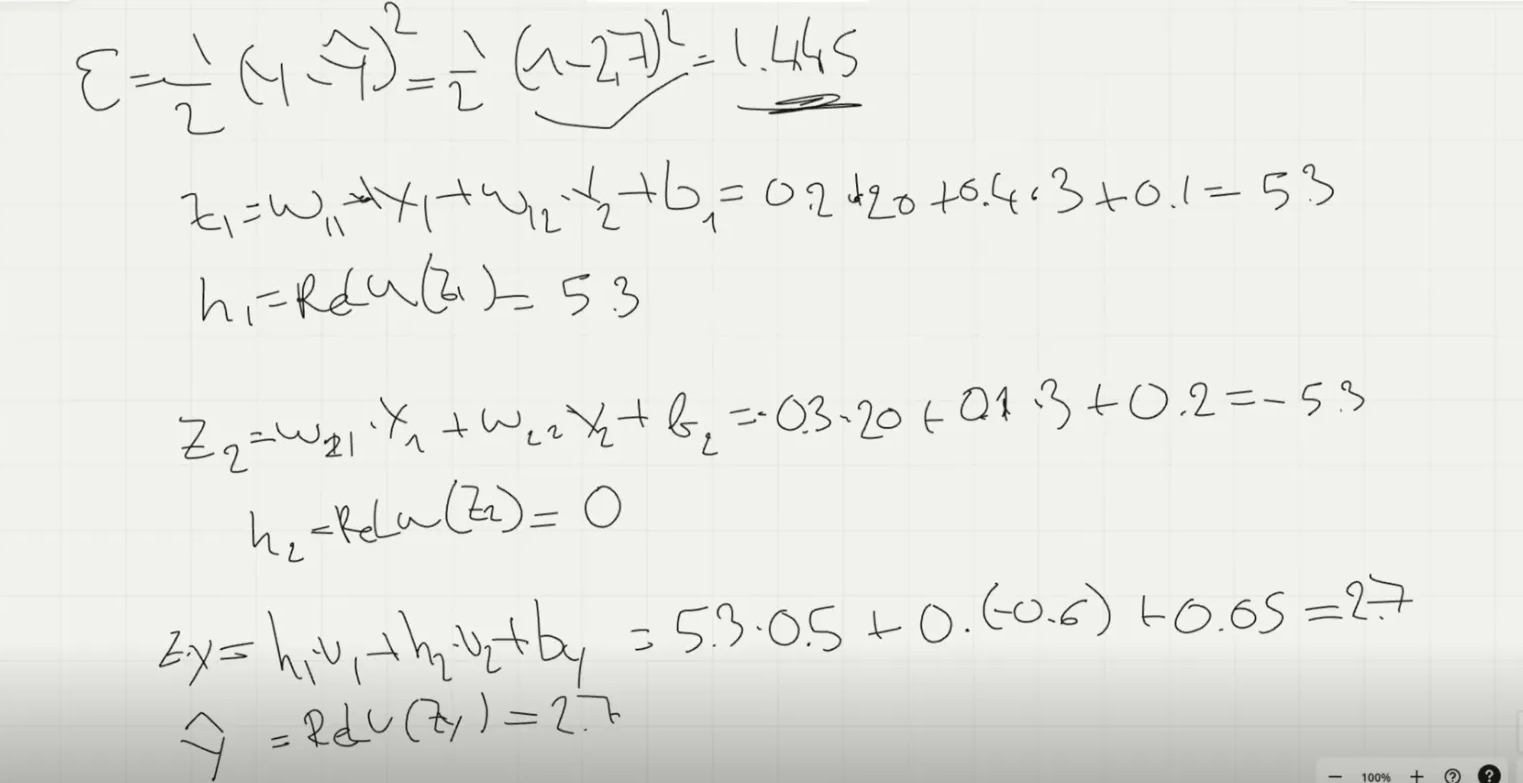

In [9]:
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_002.png")

## Deep_Learning_Train_003 — Backprop en capa de salida, peso v1

**Resumida:** El gradiente del error respecto a ŷ es 1.7. La culpa de v1 es 9.01. v1 pasa de 0.5 a ~0.4009.

**Detallada:** Ahora la red va hacia atrás buscando culpables. 
- Primero calcula cuánto afecta la predicción al error: ŷ - y = 2.7 - 1 = 1.7. 
- Ese 1.7 es la señal de error que se va a propagar hacia atrás. 
- Para v1, la culpa es 1.7 × h1 = 1.7 × 5.3 = 9.01 — grande porque h1 era grande. 
- Se actualiza: v1_nuevo = 0.5 - 0.011 × 9.01 = 0.4009. 

El learning rate η=0.011 controla cuánto se mueve — pequeño para no pasarse.

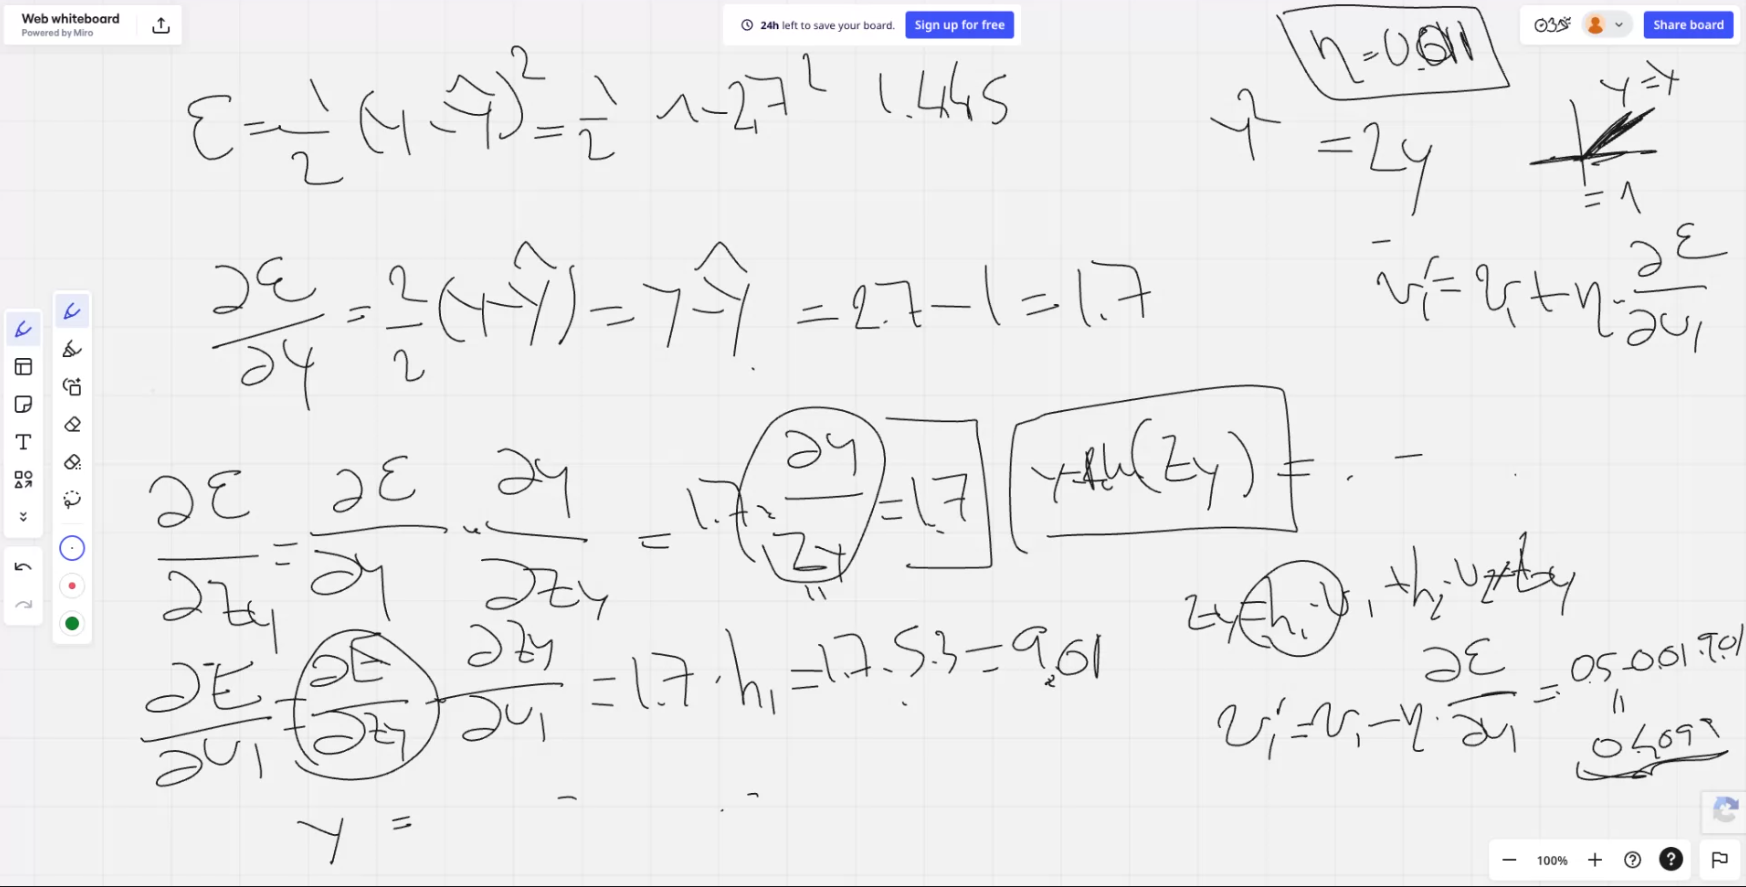

In [10]:
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_003.png")

## Deep_Learning_Train_004 — Backprop en capa de salida, peso v2 y bias

**Resumida:** v2 no se mueve porque h2=0. El bias pasa de 0.65 a 0.633.

**Detallada:** Para v2 la culpa es 1.7 × h2 = 1.7 × 0 = 0. 
- Gradiente cero significa que el peso no se mueve en absoluto. 
- La neurona que ReLU apagó no recibe ningún ajuste — no contribuyó al error, no se toca. 
- El bias de salida sí se ajusta: su gradiente es simplemente 1.7, y se actualiza: 0.65 - 0.01 × 1.7 = 0.633. 

Los pesos que más contribuyeron al error son los que más se ajustan. Los que no activaron no cambian.

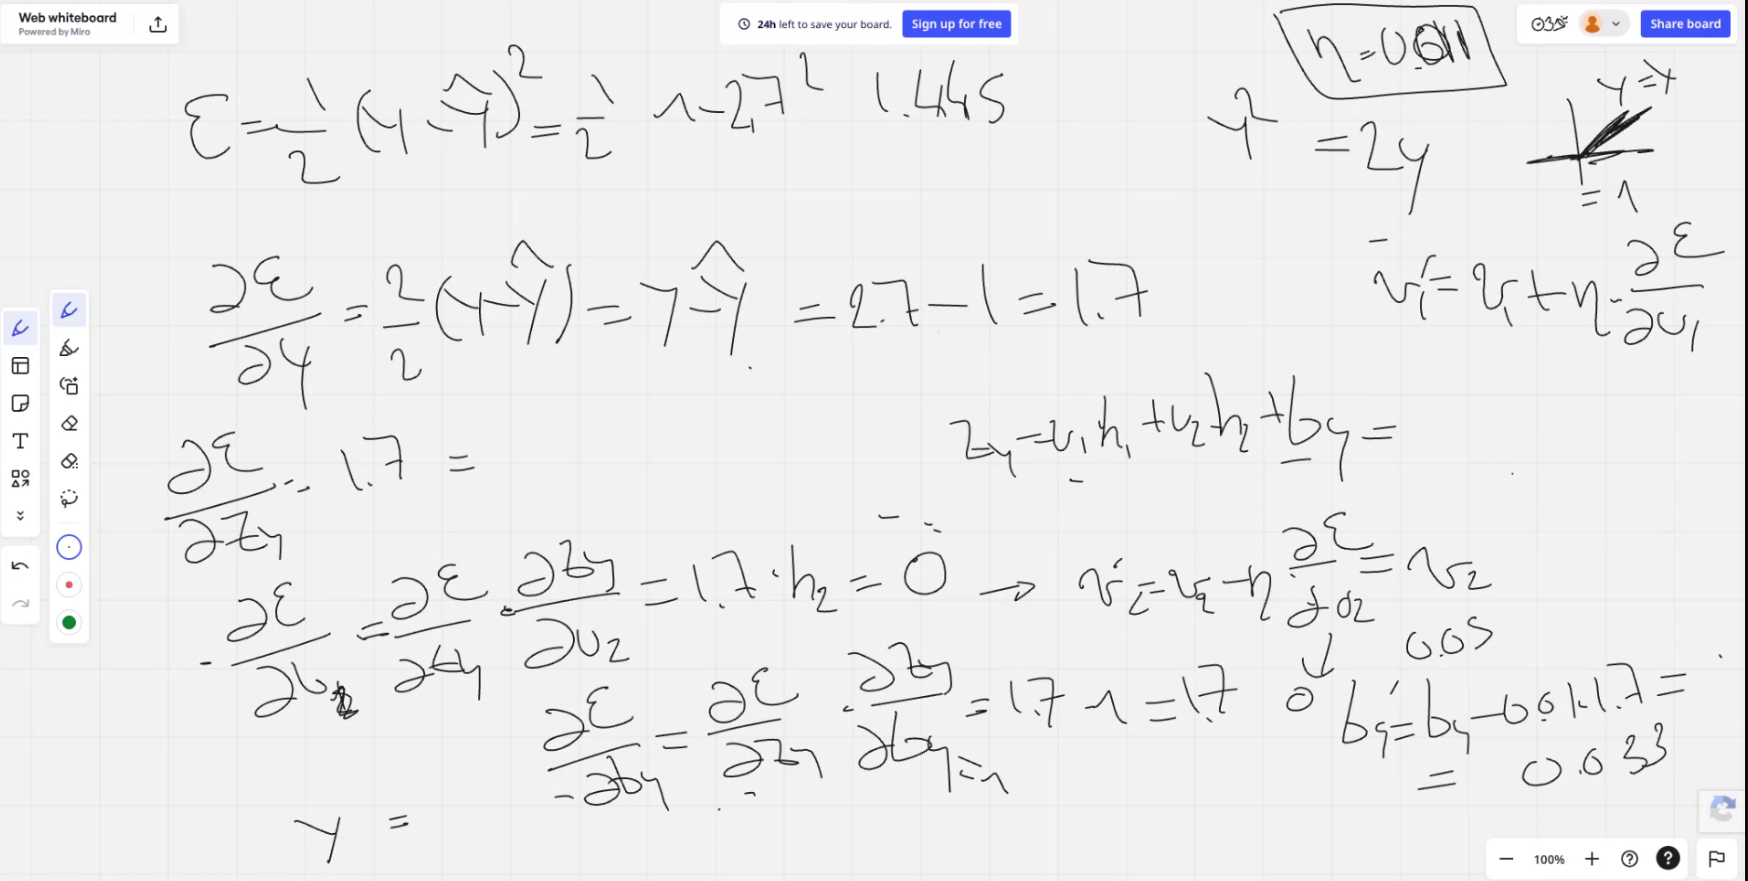

In [11]:
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_004.png")

## Deep_Learning_Train_005 — Backprop llega a la capa oculta, peso w11

**Resumida:** El gradiente llega debilitado a w11: vale 0.85. w11 pasa de 0.2 a 0.1903.

**Detallada:** La señal de error sigue viajando hacia atrás, ahora hasta los pesos de la capa oculta. 
- Para llegar a w11 tiene que atravesar más capas, y en cada paso se va diluyendo. 
- El gradiente que llega a w11 es 0.85, y el ajuste es: 0.2 - 0.011 × 0.85 = 0.1903 — un cambio muy pequeño comparado con v1. 

Cuanto más lejos está un peso de la salida, más débil llega la señal. Esto tiene nombre: **vanishing gradient**, y es uno de los problemas clásicos del deep learning. 

En redes muy profundas los pesos de las primeras capas apenas aprenden porque la señal llega casi a cero.

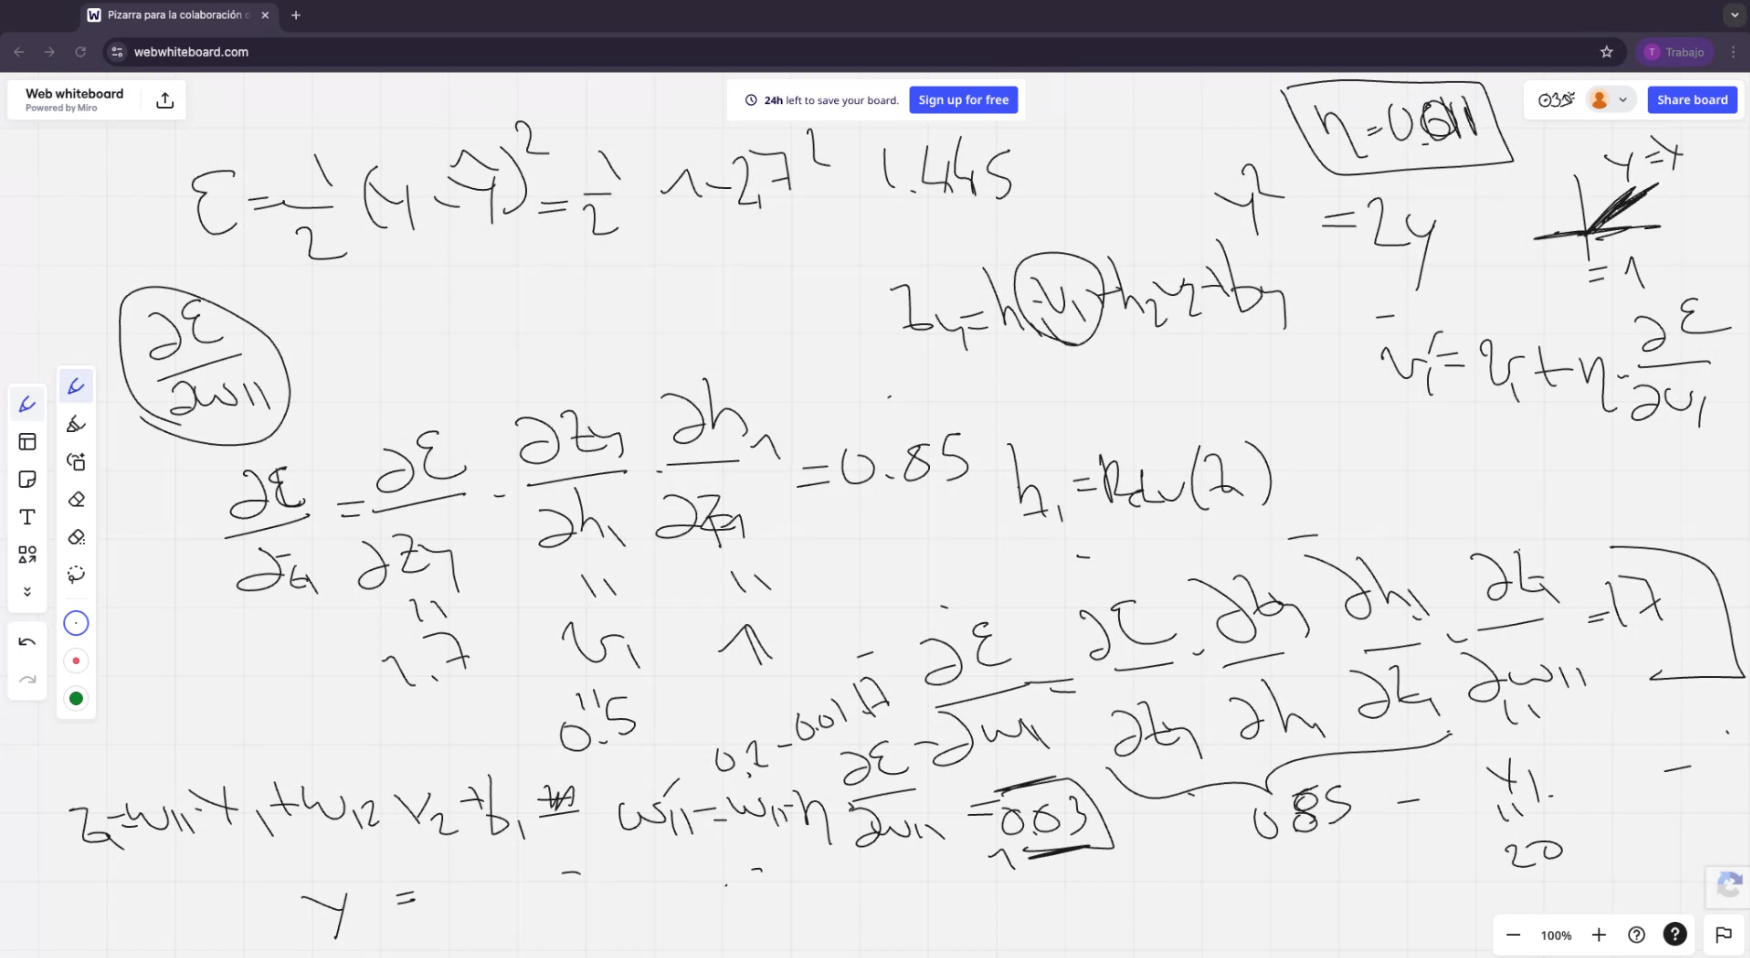

In [12]:
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_005.png")

## MLP — El proceso completo de entrenamiento

Una red neuronal es un sistema que aprende por ensayo y error, igual que un humano.

---

**1º. 001 - La estructura:** Tienes inputs (X1, X2), neuronas ocultas y una salida. Cada flecha tiene un peso — un número que dice cuánto importa esa conexión.

**2º. 002 - La red hace una predicción :** Con los pesos actuales recorre la red de izquierda a derecha. Cada neurona suma sus inputs, aplica ReLU, y pasa el resultado a la siguiente capa. Al final sale un número: la predicción (ŷ=2.7).

**3º. 002 - Cálculo el error:** Compara la predicción (2.7) con la realidad (1). El error es 1.445. Cuanto más grande, peor.

**4º. 003 - Busca quién tiene la culpa en la capa de salida:** Va hacia atrás. Calcula cuánto contribuyó cada peso al error. Los pesos de neuronas que activaron fuerte tienen más culpa. Los de neuronas apagadas por ReLU, ninguna.

**5º. 004 - Ajusta los pesos de salida:** v1 se movió mucho (h1=5.3 era grande). v2 no se movió (h2=0, ReLU la apagó). El bias pasó de 0.65 a 0.633.

**6º. 005 - Propaga la culpa hacia atrás hasta la capa oculta:** El mismo proceso llega ahora a los pesos de la capa oculta. Para w11, el gradiente resulta 0.85 y el peso pasa de 0.2 a 0.1903 — un ajuste pequeño. Cuanto más lejos está un peso de la salida, más débil llega la señal de error. Ese problema tiene nombre: vanishing gradient.


**7º. Repite miles de veces:** Cada vuelta completa — predicción, error, ajuste de todos los pesos — es una **época**. Con cada época el error baja un poco y la red mejora.

---

## Conceptos clave

| Concepto | Qué es |
|---|---|
| **Input (entrada)** | Los datos que le metes al modelo. En nuestro ejemplo: edad, salario, historial... Números que describen cada caso |
| **Peso (weight)** | El número en cada flecha que dice cuánto importa esa conexión. El modelo los ajusta durante el entrenamiento |
| **Bias** | Un número extra que tiene cada neurona para ajustar su sensibilidad. Como el volumen base antes de que llegue ninguna señal |
| **Capa oculta (hidden layer)** | Las neuronas intermedias entre la entrada y la salida. Detectan combinaciones y patrones en los datos. El usuario no las ve ni las controla directamente |
| **Capa de salida (output)** | La última neurona. Da la predicción final — en clasificación binaria, una probabilidad entre 0 y 1 |
| **ReLU** | Función de activación. Si el valor que llega es negativo lo convierte en 0 (apaga la neurona). Si es positivo lo deja pasar. Introduce no-linealidad en la red |
| **Sigmoid** | Función de activación usada en la salida. Convierte cualquier número en un valor entre 0 y 1 — ideal para probabilidades |
| **Forward pass** | El recorrido de los datos de izquierda a derecha por la red hasta obtener una predicción |
| **Error / Loss** | La diferencia entre lo que predijo el modelo y la realidad. El objetivo del entrenamiento es minimizarlo |
| **Backpropagation** | El recorrido de vuelta — de derecha a izquierda — repartiendo la culpa del error entre todos los pesos |
| **Gradiente** | El número que dice cuánto contribuyó cada peso al error y en qué dirección hay que moverlo |
| **Época** | Una vuelta completa por todos los datos de entrenamiento |
| **Learning rate** | Cuánto se mueve cada peso en cada ajuste. Demasiado grande = se pasa. Demasiado pequeño = tarda siglos |
| **Vanishing gradient** | La señal de error se debilita al viajar hacia atrás. Los pesos más lejanos de la salida aprenden muy poco |

# **CNN — Redes Neuronales Convolucionales**

## **EXPLICACIÓN DEL MODELO**

### Red neuronal para imágenes

La imagen muestra cómo una CNN procesa una foto para clasificarla.

---

**Input Layer — la imagen entra en 3 capas**
La foto se divide en 3 matrices de píxeles: una roja, una verde, una azul (RGB). Son los datos en bruto.

**Convolution Layer — busca patrones locales**
Un filtro pequeño recorre toda la imagen buscando patrones: bordes, esquinas, texturas. No mira la imagen entera de golpe — mira trocito a trocito. El resultado es un mapa de dónde aparece cada patrón.

```python
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
```
- `32` → número de filtros (patrones distintos que busca)
- `(3, 3)` → tamaño del trocito que analiza cada vez
- `input_shape=(28, 28, 1)` → imagen de 28×28 píxeles en escala de grises

**Pooling Layer — reduce y simplifica**
Coge el mapa anterior y lo resume. Se queda con lo importante y descarta detalles irrelevantes. Hace la red más rápida y evita que memorice detalles sin importancia.

```python
model.add(MaxPooling2D((2, 2)))
```
- Divide la imagen en bloques de 2×2 y se queda solo con el valor más alto de cada bloque. Reduce a la mitad el tamaño.

**Flatten — convierte la matriz en una lista**
Antes de pasar al MLP, la imagen (que es una matriz 2D) se convierte en un vector 1D — una lista de números que la capa densa puede procesar.

```python
model.add(Flatten())
```

**Fully Connected Layer — igual que el MLP**
Aquí ya no hay imagen, solo números. Es exactamente igual que el MLP que hemos visto — neuronas conectadas a todas las de la capa siguiente, tomando la decisión final.

```python
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
```

**Softmax Output — probabilidad por clase**
En vez de sí/no, da una probabilidad para cada categoría posible. Ejemplo: perro 80%, gato 15%, pájaro 5%. La clase ganadora es la predicción.

```python
model.add(Dense(10, activation='softmax'))
```
- `10` → 10 categorías posibles, una probabilidad para cada una

**Compilación del modelo**
```python
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
```
- `SGD` → el algoritmo que ajusta los pesos (similar al gradient descent que vimos)
- `momentum=0.9` → ayuda a no quedarse atascado en el camino hacia el mínimo de error
- `categorical_crossentropy` → la función de error para clasificación con más de 2 clases

---

**La diferencia clave con el MLP:** 
El MLP recibe números directamente (edad, salario...). La CNN añade antes un procesado especial para convertir píxeles en números con significado. Después el final es igual.

## **ANÁLISIS CNN con TensorFlow: Fashion MNIST**

### DESCRIPCIÓN DETALLADA

---

**Paso 0 - Exploramos los datos**

*Resumida:* El dataset es Fashion-MNIST: 70.000 imágenes en escala de grises de 28×28 píxeles con 10 categorías de ropa.

*Detallada:* Cada imagen es una matriz de 28×28 números entre 0 y 255. El 0 es negro, el 255 es blanco, los valores intermedios son grises. El modelo tiene que aprender a distinguir entre 10 categorías: camiseta, pantalón, jersey, vestido, abrigo, sandalia, camisa, zapatilla, bolso y botín. Hay 60.000 imágenes para entrenar y 10.000 para evaluar.

---

**Paso 1 - Cargamos el dataset**

*Resumida:* Se cargan las imágenes y se reformatean para que la CNN pueda procesarlas. La variable de salida se convierte a formato categórico.

*Detallada:* Las imágenes se reformatean de (28, 28) a (28, 28, 1) — el 1 indica un solo canal (escala de grises). Si fueran en color serían 3 canales (RGB). La variable de salida pasa de un número (0-9) a un vector de 10 posiciones donde solo hay un 1 — la clase correcta. Ejemplo: la clase 2 se convierte en [0,0,1,0,0,0,0,0,0,0]. Esto se llama one-hot encoding.

```python
def load_dataset():
    (trainX, trainY), (testX, testY) = fashion_mnist.load_data()
    trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
    testX = testX.reshape((testX.shape[0], 28, 28, 1))
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY
```

---

**Paso 2 - Preparamos los píxeles**

*Resumida:* Los píxeles pasan de valores 0-255 a valores 0-1.

*Detallada:* Las redes neuronales funcionan mejor con números pequeños. Dividir entre 255 convierte todos los píxeles al rango 0-1 sin perder información. Esto se llama normalización y hace que el entrenamiento sea más estable y rápido.

```python
def prep_pixels(train, test):
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm
```

---

**Paso 3 - Definimos las capas de la red**

*Resumida:* Se construye la CNN con sus capas: convolución, pooling, flatten, densa y salida softmax.

*Detallada:* La red tiene 5 capas en orden:

- **Conv2D(32, (3,3))** → 32 filtros que recorren la imagen en trocitos de 3×3 buscando patrones (bordes, texturas, formas). ReLU activa solo los patrones detectados.
- **MaxPooling2D((2,2))** → Divide el resultado en bloques de 2×2 y se queda solo con el valor más alto. Reduce el tamaño a la mitad y descarta detalles irrelevantes.
- **Flatten()** → Convierte la matriz 2D resultante en una lista 1D de números. Necesario para pasar al MLP.
- **Dense(100, relu)** → Capa MLP clásica. 100 neuronas que combinan todos los patrones detectados.
- **Dense(10, softmax)** → 10 neuronas de salida, una por categoría. Softmax convierte los valores en probabilidades que suman 1.

```python
def define_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dense(10, activation='softmax'))
    opt = SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model
```

---

**Paso 4 - Evaluamos el modelo con KFold**

*Resumida:* Se divide el dataset en 5 partes y se entrena 5 veces, usando cada vez una parte distinta como test.

*Detallada:* KFold evita que el resultado dependa de cómo se partieron los datos por suerte. Divide los datos en 5 grupos. En cada ronda entrena con 4 grupos y valida con el que queda. Al final tienes 5 resultados distintos y puedes calcular la media y la variabilidad. Cada entrenamiento hace 10 épocas — 10 pasadas completas por todos los datos de entrenamiento.

```python
def evaluate_model(dataX, dataY, n_folds=5):
    kfold = KFold(n_folds, shuffle=True, random_state=1)
    for train_ix, test_ix in kfold.split(dataX):
        model = define_model()
        history = model.fit(trainX, trainY, epochs=10, batch_size=32,
                            validation_data=(testX, testY), verbose=0)
```

---

**Paso 5 - Diagnóstico**

*Resumida:* Se pintan las curvas de loss y accuracy para ver cómo aprendió el modelo en cada fold.

*Detallada:* Para cada una de las 5 ejecuciones se muestran dos gráficos. El de arriba muestra el error (Cross Entropy Loss) — debe bajar con las épocas. El de abajo muestra el accuracy — debe subir. La línea azul es el entrenamiento, la naranja es la validación. Si la azul baja mucho y la naranja no, el modelo está memorizando en lugar de aprender (overfitting).

---

**Paso 6 - Performance**

*Resumida:* Se calcula el accuracy medio de las 5 ejecuciones y se muestra en un boxplot.

*Detallada:* Al tener 5 resultados distintos podemos ver no solo cuánto acierta el modelo de media, sino también cuánto varía. Un boxplot estrecho y alto indica un modelo estable y preciso. Uno ancho indica que los resultados dependen mucho de cómo se partieron los datos.

---

**Paso 7 - Run**

*Resumida:* Función que ejecuta todo el pipeline completo de una vez.

*Detallada:* Encadena todos los pasos: carga datos → normaliza píxeles → evalúa con KFold → pinta diagnóstico → muestra performance. Es el punto de entrada al código.

---

**Paso 8 - Guardamos el modelo**

*Resumida:* Se entrena el modelo con todos los datos y se guarda en disco.

*Detallada:* Hasta ahora el modelo se entrenaba 5 veces con partes del dataset para evaluarlo. Ahora se entrena una vez con todos los datos de entrenamiento para tener el modelo final. Se guarda en formato `.keras` para poder cargarlo después sin tener que reentrenar.

---

**Paso 9 - Errores**

*Resumida:* Se identifican y visualizan los casos que el modelo clasificó mal.

*Detallada:* Se comparan las predicciones del modelo con las etiquetas reales. Los casos donde no coinciden son los errores. Se muestran los primeros 25 con la etiqueta real y la predicha. Sirve para entender qué tipos de ropa confunde el modelo — por ejemplo, es normal que confunda camisas con camisetas o zapatillas con botines.

---

**Paso 10 - Evaluamos el modelo final**

*Resumida:* Se carga el modelo guardado y se evalúa sobre los 10.000 casos de test.

*Detallada:* Con el modelo ya guardado se hace una evaluación definitiva sobre datos que nunca ha visto durante el entrenamiento. El resultado es el accuracy real del modelo en producción.

---

**Paso 11 - Hacemos predicciones**

*Resumida:* Se carga una imagen externa y el modelo predice qué categoría de ropa es.

*Detallada:* Se carga una imagen nueva (no del dataset), se preprocesa igual que durante el entrenamiento (escala de grises, 28×28, normalización) y se pasa por el modelo. El resultado es un número del 0 al 9 que indica la categoría predicha. Esto simula el uso real del modelo en producción.

---

### RESUMEN PROCESO COMPLETO

Una CNN es una red neuronal diseñada específicamente para procesar imágenes. Añade capas de filtrado visual antes del MLP clásico.

**1. Los datos** → 70.000 imágenes de ropa en escala de grises, 10 categorías posibles

**2. Preprocesado** → Las imágenes se reformatean y los píxeles se normalizan a 0-1

**3. La red** → Convolución detecta patrones visuales → Pooling reduce y simplifica → Flatten convierte a lista → Dense combina patrones → Softmax da probabilidad por categoría

**4. Entrenamiento con KFold** → 5 rondas de entrenamiento para una evaluación robusta, 10 épocas cada una

**5. Diagnóstico** → Curvas de loss y accuracy para detectar si aprende bien o memoriza

**6. Guardado** → Se entrena con todos los datos y se guarda el modelo final

**7. Producción** → Se carga una imagen nueva y el modelo predice qué prenda de ropa es

# **REDES RECURRENTES: RNN, LSTM, GRU**

## **EXPLICACIÓN DEL MODELO**

### 1. RESUMEN CONCEPTUAL
Las redes neuronales tradicionales ven los datos como fotos aisladas. Las **RNN** los ven como una película. Su función es procesar secuencias donde el orden importa (texto, audio, series temporales). 
- **El problema:** Las RNN básicas sufren de "amnesia" (gradiente desvanecido).
- **La solución:** LSTM y GRU, que usan "puertas" para decidir qué recordar.

---

### 2. DETALLE TÉCNICO SEGÚN EL PDF Y TUS IMÁGENES

#### A. RNN Tradicional (La base)
Es el modelo más simple que aparece en tu primera imagen. 
- **Estado Oculto ($h_t$):** Es la "memoria de trabajo". Se actualiza en cada paso, pero se diluye rápido. Si la frase es larga, la red olvida cómo empezó.

#### B. LSTM: La Memoria de Largo Plazo (Imagen 2)
El PDF detalla que la LSTM es una variante diseñada para mantener información por mucho tiempo. Se basa en:

1. **Estado de Celda (Cell State):** Es la línea superior en tu diagrama. Es una cinta transportadora de información que atraviesa toda la secuencia con cambios mínimos.
2. **Puerta de Olvido (Forget Gate):** ¿La información anterior sigue siendo relevante? Si no, se borra. (Ej: Cambias de sujeto en una frase).
3. **Puerta de Entrada (Input Gate):** ¿Qué información nueva de la palabra actual vale la pena meter en la "cinta transportadora"?
4. **Puerta de Salida (Output Gate):** De todo lo que tenemos guardado, ¿qué vamos a mostrarle al siguiente paso?

#### C. GRU: La Versión Eficiente
El PDF también menciona las GRU (Gated Recurrent Units). Son una simplificación de las LSTM:
- **Diferencia:** Combinan la puerta de olvido y de entrada en una sola ("Update Gate").
- **Ventaja:** Tienen menos parámetros, son más rápidas de entrenar y a menudo logran resultados similares a las LSTM.

---

### 3. FRAGMENTOS DE IMPLEMENTACIÓN (RELEVANCIA)
En el código que analizamos de tu notebook, estas arquitecturas se invocan así:

- `layers.SimpleRNN(units)` -> Para problemas muy cortos (poco usado).
- `layers.LSTM(units)` -> El estándar cuando la precisión es prioridad en secuencias largas.
- `layers.GRU(units)` -> Cuando buscas velocidad de entrenamiento sin perder mucha precisión.

---

### 4. RESUMEN FINAL
1. **RNN:** La idea original (procesar secuencias), pero con mala memoria.
2. **Estado Oculto:** Memoria a corto plazo (presente en todas).
3. **Estado de Celda:** Memoria a largo plazo (solo en LSTM).
4. **Puertas (Entrada, Olvido, Salida):** Los guardianes que deciden qué datos sobreviven al flujo del tiempo para que la red no se confunda con información irrelevante.

## **ANÁLISIS RNN: SENTIMENT ANALYSIS (IMDb)**

### 1. CARGA Y PREPROCESAMIENTO (EL FILTRO)
**Resumen:** Preparas el texto para que la red pueda "leerlo". Las máquinas no entienden palabras, solo números y dimensiones fijas.

* **Detalle:**
    * `max_features = 10000`: Solo te quedas con las 10,000 palabras más comunes. Ignorar el "ruido" (palabras raras) ayuda a la red a generalizar.
    * `pad_sequences`: Es crítico. Las redes neuronales requieren matrices de tamaño fijo. Si una reseña tiene 50 palabras y otra 500, esta función las iguala a 200 (`maxlen`), cortando las largas o rellenando con ceros las cortas.
    * **Punto ciego:** Si cortas por el principio (`padding='pre'`), podrías perder el contexto inicial. Si cortas por el final, podrías perder la conclusión.

---

### 2. CAPA DE EMBEDDING (EL TRADUCTOR)
**Resumen:** Es la primera capa del modelo. Transforma índices de palabras en vectores densos que capturan significado semántico.

* **Detalle:** * `Embedding(max_features, 128)`: Cada palabra se convierte en un vector de 128 números.
    * En este espacio vectorial, la palabra "excelente" y "buena" terminarán estando cerca geográficamente porque aparecen en contextos similares. Es donde la red empieza a "entender" el lenguaje.

---

### 3. ARQUITECTURA RECURRENTE: LSTM Y GRU
**Resumen:** El núcleo del notebook. Aquí decides cómo la red recordará la secuencia de la reseña.

* **Detalle:**
    * **LSTM:** Usada en tu código para manejar dependencias a largo plazo. Gracias a su "Cell State" (la autopista de información), puede recordar una negación al principio de la frase que cambia el sentido del final.
    * **GRU:** Una alternativa más ligera que también implementas. Tiene menos parámetros, lo que la hace más rápida pero a veces menos precisa en secuencias muy complejas.
    * `dropout=0.2`: Fundamental. Apaga aleatoriamente el 20% de las neuronas para evitar que la red "memorice" el dataset de entrenamiento.



---

### 4. COMPILACIÓN Y ENTRENAMIENTO (LA OPTIMIZACIÓN)
**Resumen:** Configuras cómo la red aprende de sus propios errores.

* **Detalle:**
    * `loss='binary_crossentropy'`: La función de error estándar para problemas de "Sí o No" (Positivo/Negativo).
    * `optimizer='adam'`: El estándar de la industria que ajusta la tasa de aprendizaje automáticamente.
    * `validation_split=0.2`: Reservas un 20% de los datos para ver cómo se comporta la red con reseñas que nunca ha visto antes de hacer el test final.

---

### 5. EVALUACIÓN Y DECODIFICACIÓN
**Resumen:** Verificas si el modelo sirve para algo y traduces los números a texto humano para auditar errores.

* **Detalle:**
    * El notebook incluye una función `decode_review`. Es vital para el diagnóstico. 
    * Si el modelo falla, necesitas ver la reseña original. ¿Falló porque era sarcástica? ¿Porque era muy corta? Sin decodificar, el Data Scientist está ciego.

---

### RESUMEN FINAL PARA EL ÉXITO
1.  **Datos:** Limpias y normalizas longitudes (`pad_sequences`).
2.  **Representación:** Creas un mapa de conceptos numéricos (`Embedding`).
3.  **Memoria:** Usas compuertas (`LSTM`/`GRU`) para no olvidar el contexto.
4.  **Regularización:** Usas `dropout` para no engañarte con resultados inflados.
5.  **Auditoría:** Evalúas y decodificas para entender por qué la red se equivoca.

# **ARQUITECTURAS AVANZADAS: GAN, EMBEDDINGS, AUTOENCODERS Y TRANSFORMERS**

## **MODELOS**

### 1. MODELOS GAN (Generative Adversarial Networks)
**Resumen:** Es una competencia entre dos redes para crear datos nuevos e hiperrealistas.

**Detalle:** 

- **El Generador:** Intenta crear datos (imágenes, música, texto) que parezcan reales a partir de ruido aleatorio.
- **El Discriminador:** Actúa como un juez. Intenta distinguir si los datos son reales (del dataset original) o falsificaciones creadas por el generador
- **Resultado:** Ambas redes aprenden juntas hasta que el generador es capaz de "imaginar" contenido que el discriminador ya no puede distinguir de la realidad

---

### 2. EMBEDDINGS (Representaciones Vectoriales)
**Resumen:** Traducen conceptos humanos (palabras o categorías) a un lenguaje numérico donde el "significado" se mide por la distancia física

**Detalle:** Transforman datos categóricos en vectores de baja dimensión conservando su información semántica
- **Ejemplo:** En un espacio de embedding, la palabra "gato" estará físicamente cerca de "perro" porque aparecen en contextos similares, pero lejos de "avión"
- **Uso:** Es el paso inicial obligatorio en NLP (Procesamiento de Lenguaje Natural) para que la red "entienda" relaciones entre palabras

---

### 3. AUTOENCODERS (Compresión y Reconstrucción)
**Resumen:** Redes que aprenden a resumir información y luego a reconstruirla desde ese resumen

**Detalle:** 
- **Encoder (Codificador):** Comprime los datos de entrada en una representación mucho más pequeña y eficiente
- **Decoder (Decodificador):** Toma ese "resumen" comprimido e intenta reconstruir los datos originales con la mínima pérdida de información posible
- **Uso:** Ideal para eliminar ruido de imágenes, detectar anomalías (si algo no se puede reconstruir bien, es una anomalía) o reducir dimensiones

---

### 4. TRANSFORMERS (Atención Total)
**Resumen:** La arquitectura que revolucionó la IA moderna (GPT, BERT). Su secreto es que pueden mirar toda la secuencia de datos a la vez, no paso a paso.

**Detalle:** 
- **Auto-atención (Self-Attention):** Permite al modelo asignar un "peso" o importancia a cada palabra de una frase según su relevancia con las demás 
- **Contexto:** Si la frase es "El banco está cerrado", el mecanismo de atención ayuda a la red a saber si "banco" se refiere a una entidad financiera o a un asiento basándose en las palabras de alrededor
- **Ventaja:** Son altamente paralelizables, lo que permite entrenarlos con cantidades masivas de datos mucho más rápido que las RNN

---

### RESUMEN DE USOS
| Modelo | ¿Para qué sirve? | Ventaja Clave |
| :--- | :--- | :--- |
| **GAN** | Crear caras nuevas, arte o sintetizar voz. | Genera datos nuevos realistas. |
| **Embedding** | Clasificar texto, sistemas de recomendación. | Captura similitudes semánticas. |
| **Autoencoder** | Limpiar fotos borrosas, comprimir datos. | Aprende representaciones eficientes. |
| **Transformer** | Traducción, Chatbots (ChatGPT), Resúmenes. | Captura dependencias globales de forma rápida. |

## **TABLA COMPARATIVA**


| Arquitectura | Concepto para Dummies | Componente Clave | Uso Principal |
| :--- | :--- | :--- | :--- |
| **RNN (Simple)** | Memoria a corto plazo para secuencias. | Estado Oculto ($h_t$) | Series temporales cortas. |
| **LSTM** | Memoria a largo plazo con "puertas". | Cell State + Puerta Olvido | Análisis de sentimiento y texto largo. |
| **GRU** | Versión simplificada y rápida de la LSTM. | Update Gate | Procesamiento de voz y audio. |
| **GAN** | Competencia entre un "falsificador" y un "juez". | Generador vs Discriminador | Creación de imágenes y Deepfakes. |
| **Autoencoder** | Compresión y reconstrucción de datos. | Bottleneck (Cuello botella) | Limpieza de ruido y anomalías. |
| **Embedding** | Mapa de palabras según su significado. | Espacio Vectorial | Motores de búsqueda y recomendación. |
| **Transformer** | Atención selectiva a toda la frase a la vez. | Mecanismo de Atención | ChatGPT, Traductores (BERT, GPT). |

---

### DETALLE DE FUNCIONAMIENTO

1.  **RNN/LSTM/GRU:** La clave es el **orden**. Si cambias el orden de las palabras, cambia el resultado. Son "detectives" que leen pistas una tras otra.
2.  **GAN:** El **Generador** crea basura al principio; el **Discriminador** le dice por qué es basura. Repiten esto millones de veces hasta que el Generador es un artista.
3.  **Autoencoder:** Obligas a la red a pasar un elefante por el ojo de una aguja (compresión). Para que el elefante salga igual al otro lado, la red debe aprender qué es lo más importante de un elefante.
4.  **Transformers:** No leen de izquierda a derecha. Miran toda la página y dicen: "Esta palabra de abajo es la que explica el sujeto de arriba". Es **paralelismo puro**.

Resumen Final:
- Usa RNN/LSTM si tienes secuencias donde el pasado inmediato es crítico.
- Usa Transformers si tienes potencia de cómputo y necesitas entender contextos globales (el estándar actual).
- Usa GANs para crear.
- Usa Autoencoders para limpiar o comprimir.

## **FUNCIONES**


### 1. FUNCIONES DE ACTIVACIÓN (El "Disparador" de la neurona)
Determinan si la información debe pasar o no al siguiente nivel.

| Función | Uso Recomendado | Por qué usarla |
| :--- | :--- | :--- |
| **ReLU** | Capas ocultas (Estándar) | Evita que el gradiente muera; es computacionalmente barata. |
| **Sigmoid** | Capa de salida (Binaria) | Escala los valores entre 0 y 1. Ideal para "Sí/No". |
| **Softmax** | Capa de salida (Multiclase) | Convierte salidas en probabilidades que suman 100%. |
| **Tanh** | Capas ocultas | Escala entre -1 y 1. Mejor que Sigmoid para capas intermedias. |

---

### 2. FUNCIONES DE PÉRDIDA (Loss Functions - ¿Cuánto nos equivocamos?)
Miden la distancia entre la predicción y la realidad.

| Tipo de Problema | Función de Pérdida | Notas del PDF |
| :--- | :--- | :--- |
| **Clasificación Binaria** | `BinaryCrossentropy` | Para 2 clases exclusivas (ej. Positivo/Negativo). |
| **Clasificación Multiclase** | `CategoricalCrossentropy` | Para más de 2 clases con etiquetas *One-Hot*. |
| **Regresión** | `MeanSquaredError` (MSE) | Minimiza el cuadrado de los errores (penaliza fallos grandes). |
| **Regresión Robusta** | `Huber` | Mezcla MSE y MAE; menos sensible a valores atípicos. |

---

### 3. OPTIMIZADORES (El "Cerebro" del entrenamiento)
Algoritmos que ajustan los pesos para minimizar la pérdida.

| Optimizador | Perfil de Uso | Características Clave |
| :--- | :--- | :--- |
| **Adam** | El "todoterreno" | **Recomendación Junior:** Úsalo por defecto. Adapta la tasa de aprendizaje. |
| **SGD** | Problemas simples/estables | Descenso de gradiente estocástico. Más lento pero fiable. |
| **RMSprop** | Secuencias (RNN/LSTM) | Ideal para datos temporales o lenguaje natural. |
| **AdamW** | Modelos tipo Transformer | Incluye mejora en la penalización de pesos (Weight Decay). |

---

### RESUMEN RÁPIDO PARA TU PROYECTO
* **Si clasificas texto (Sentimiento):** `ReLU` en ocultas + `Sigmoid` en salida + `BinaryCrossentropy` + `Adam`.
* **Si clasificas imágenes (Multiclase):** `ReLU` en ocultas + `Softmax` en salida + `CategoricalCrossentropy` + `Adam`.
* **Si predices un precio (Regresión):** `ReLU` en ocultas + `Linear` en salida + `MSE` + `Adam`.

## **MODELO: EMBEDDINGS**

### 1. RESUMEN
En lugar de enseñarle a una IA a entender palabras (que lleva semanas), usas un modelo que ya "leyó" internet. Este modelo toma una frase y la traduce a una lista de números (vector) que representa su significado exacto.

---

### 2. DETALLE TÉCNICO DEL FLUJO

#### A. El Modelo Preentrenado
* **Detalle:** El notebook utiliza una librería (probablemente `sentence-transformers`) para cargar un modelo que ya sabe que "perro" y "canino" son casi lo mismo.
* **Importancia:** Como Junior, esto es clave: **No siempre hay que entrenar**. Usar embeddings preentrenados ahorra miles de euros en computación y tiempo.

#### B. Generación de Vectores (Encoding)
* **Detalle:** Al pasarle una frase al modelo, este devuelve un vector de alta dimensión (ej. 384 o 768 números).
* **La magia:** Si calculas la distancia entre el vector de "Coche" y "Vehículo", será muy pequeña. Si lo haces entre "Coche" y "Manzana", será muy grande.

#### C. Aplicación Práctica: Similitud de Coseno
* **Detalle:** El notebook usa matemáticas para comparar qué tan alineados están dos vectores. 
* **Resultado:** Esto permite crear buscadores inteligentes que no buscan "palabras exactas", sino "conceptos similares".

---

### 3. FRAGMENTOS DE LÓGICA CRÍTICA

`model.encode(sentences)`
- Este comando es el corazón del notebook. Transforma el lenguaje humano en coordenadas en un mapa multidimensional.

`cosine_similarity(vec1, vec2)`
- Es la métrica que decide si dos frases dicen lo mismo aunque usen palabras distintas.

---

### 4. RESUMEN FINAL PARA DUMMIES
1.  **Entrada:** Frases de texto humano.
2.  **Caja Negra (Embedding):** El modelo preentrenado traduce las frases a coordenadas matemáticas.
3.  **Salida:** Comparación de cercanía. Si las coordenadas están cerca, las frases significan lo mismo.
4.  **Uso real:** Así es como Google entiende tu búsqueda aunque escribas con faltas o uses sinónimos.

## **MODELO: GAN (GENERATIVE ADVERSARIAL NETWORKS)**

### 1. EL DUELO CREATIVO (RESUMEN)
Una GAN no es una red, son **dos redes enfrentadas** en un juego de suma cero. Tu notebook implementa este "duelo" para generar imágenes de 128x128 píxeles. Una intenta engañar y la otra intenta no ser engañada.

---

### 2. DETALLE TÉCNICO DE LOS COMPETIDORES

#### A. El Generador (El Falsificador)
* **Entrada:** Un vector de ruido aleatorio (latente).
* **Función:** Usa capas `Conv2DTranspose` (convoluciones inversas) para transformar ese ruido en una imagen de 128x128.
* **Objetivo:** Aprender qué rasgos hacen que una imagen parezca real para que el Discriminador la acepte como verdadera.

#### B. El Discriminador (El Detective)
* **Entrada:** Imágenes reales (del dataset) e imágenes falsas (del Generador).
* **Función:** Es una CNN (Red Neuronal Convolucional) clásica que clasifica: 1 para "Real", 0 para "Falso".
* **Objetivo:** Volverse un experto en detectar imperfecciones en las creaciones del Generador.

---

### 3. FRAGMENTOS DE LÓGICA CRÍTICA (TU CÓDIGO)

`LeakyReLU`
- Notas que el notebook usa `LeakyReLU` en lugar de `ReLU` estándar. 
- **Razón:** En las GANs, si una neurona muere (da 0), el entrenamiento se detiene. `LeakyReLU` deja pasar un poco de información negativa para que el gradiente siga fluyendo.

`imagen_generada = 0.5 * imagen_generada + 0.5`
- Al final de tu notebook reescalas la imagen. 
- **Razón:** El Generador suele usar una activación `tanh` (que devuelve valores entre -1 y 1). Para que `matplotlib` muestre la imagen correctamente, debes llevarla al rango [0, 1].

---

### 4. RESUMEN FINAL PARA DUMMIES
1.  **El Generador** dibuja algo basado en ruido aleatorio.
2.  **El Discriminador** mira el dibujo y le dice: "Esto es falso, los bordes no son así".
3.  **El Generador** ajusta sus pesos y lo intenta de nuevo.
4.  **Ciclo:** Tras miles de épocas, el Generador se vuelve un "maestro falsificador" y el Discriminador ya no puede distinguir la realidad de la ficción.

---

### DIAGNÓSTICO BRUTAL
Las GANs son extremadamente inestables. Si el Discriminador se vuelve demasiado bueno muy rápido, el Generador nunca aprenderá (gradiente desvanecido). Si ves que tus imágenes generadas son solo manchas grises tras muchas épocas, es que el equilibrio del duelo se ha roto. Como Junior, tu reto aquí es **ajustar los Learning Rates** para que ambos competidores evolucionen al mismo ritmo.

# **NLP — Natural Language Processing**

## **EXPLICACIÓN DEL MODELO**

### **1. ¿Qué es NLP?**

NLP es la disciplina que enseña a las máquinas a entender, analizar y generar lenguaje humano — texto escrito, hablado, organizado.

Es la base de todo lo que conoces como ChatGPT, Claude, o Llama. Sin NLP no existirían.

NLP vive en la intersección de tres áreas:
- **Machine Learning** → aprende patrones
- **Deep Learning** → redes neuronales profundas
- **Lingüística** → reglas del lenguaje humano

Dentro del NLP hay dos grandes ramas:
- **NLU (Natural Language Understanding)** → la máquina *entiende* lo que le dices. Ejemplo: detectar si una reseña es positiva o negativa.
- **NLG (Natural Language Generation)** → la máquina *genera* texto. Ejemplo: un chatbot que te responde, o un corrector automático.

### **2. Casos de uso — para qué sirve NLP en el mundo real**

- **Análisis de sentimiento** → ¿esta reseña es positiva o negativa?
- **Análisis de emociones** → ¿el texto expresa alegría, miedo, enfado?
- **Clasificación de emails** → spam o no spam
- **Chatbots y asistentes virtuales** → generan respuestas en lenguaje natural
- **Autocorrector y autocompletado** → predice la siguiente palabra
- **Resumen de documentos** → extrae lo más importante de un texto largo
- **Traducción automática** → Google Translate, DeepL
- **Extracción de información** → leer un contrato y sacar fechas, nombres, importes

### **3. Librerías principales**


| Librería | Para qué sirve |
|---|---|
| **NLTK** | Clásica, académica. Buena para aprender los fundamentos |
| **SpaCy** | Industrial, rápida, moderna. La que se usa en proyectos reales |
| **TensorFlow** | Framework de deep learning para modelos NLP complejos |
| **Hugging Face** | El gran almacén de modelos preentrenados (BERT, GPT, etc.) |
| **PyTorch** | Framework flexible, muy usado en investigación |

### **4. Vocabulario básico que necesitas entender**

**Documento** → Un trozo de texto. Puede ser una frase, un párrafo o un artículo entero. En un dataset, suele ser una fila.

**Corpus** → La colección de todos los documentos. Es el dataset completo de texto sobre el que trabajas. Ejemplo: 1.000 reseñas de películas.

**Diccionario (vocabulario)** → El conjunto de todas las palabras únicas que aparecen en el corpus. Se excluyen las stopwords y palabras poco frecuentes.

**Tokenización** → Troceаr el texto en unidades más pequeñas llamadas tokens. Hay dos tipos:
- Por palabras: "Me encanta NLP" → ["Me", "encanta", "NLP"]
- Por frases: "Me encanta NLP. Es divertido." → ["Me encanta NLP.", "Es divertido."]

**Stopwords** → Palabras que no aportan significado: artículos, conjunciones, preposiciones. Ejemplos: "el", "y", "de", "en". Se eliminan antes de analizar el texto.

### **5. El problema fundamental del NLP**

**Las redes neuronales no entienden texto. Solo entienden números.**

Por eso hay que "traducir" cada palabra a un número o conjunto de números antes de dársela al modelo. Eso es lo que hacen todas las técnicas que vienen a continuación.

### **6. Transformaciones básicas — cómo convertir texto en números**


#### 6.1 One Hot Encoding

La forma más simple. Se crea un diccionario con todas las palabras únicas del corpus. Cada palabra se representa como un vector de ceros con un único 1 en la posición que le corresponde.

Ejemplo con el diccionario ["dogs", "bark", "loudly", "the", "trees"]:
- "dogs" → [1, 0, 0, 0, 0]
- "bark" → [0, 1, 0, 0, 0]
- "loudly" → [0, 0, 1, 0, 0]

Una frase completa se convierte en una matriz donde cada fila es una palabra.

**Problema:** Si el diccionario tiene 10.000 palabras, cada vector tiene 10.000 posiciones con un solo 1. Enorme e ineficiente. Y no captura ninguna relación entre palabras — "gato" y "perro" son igual de distintos que "gato" y "avión".

---

#### 6.2 Bag of Words (BoW)

En vez de marcar presencia con 0 y 1, cuenta cuántas veces aparece cada palabra en el documento.

Ejemplo con 4 frases y el diccionario ["both", "get", "have", "it", "layers", "ogres", "onions", "we", "you"]:

| Frase | both | get | have | layers | ogres | onions |
|---|---|---|---|---|---|---|
| "onions have layers" | 0 | 0 | 1 | 1 | 0 | 1 |
| "ogres have layers" | 0 | 0 | 1 | 1 | 1 | 0 |
| "you get it?" | 0 | 1 | 0 | 0 | 0 | 0 |

**Ventaja:** Simple y funciona bien para clasificación de texto.
**Problema:** No sabe nada del orden de las palabras. "El perro muerde al hombre" y "El hombre muerde al perro" son idénticos para BoW.

---

#### 6.3 N-grams (Bi-grams)

Solución al problema del orden: en vez de mirar palabras sueltas, mira pares (o tríos) de palabras consecutivas.

Ejemplo con "dogs bark loudly":
- Bi-gramas: ["dogs bark", "bark loudly"]

El diccionario ahora incluye estas combinaciones. Así el modelo sabe que "dogs" y "bark" suelen aparecer juntos.

**Ventaja:** Captura algo de contexto local.
**Problema:** El diccionario se dispara en tamaño. Con 3-grams o 4-grams se vuelve inmanejable.

```python
from sklearn.feature_extraction.text import CountVectorizer
bigram = CountVectorizer(ngram_range=(1, 2))
X = bigram.fit_transform(sentences)
```

---

#### 6.4 TF-IDF

La más inteligente de las básicas. No solo cuenta cuántas veces aparece una palabra — también penaliza las palabras que aparecen en todos los documentos (porque no son informativas).

La fórmula es:
**TFIDF = TF × log(N / DF)**

- **TF** (Term Frequency) → cuántas veces aparece la palabra en este documento
- **N** → número total de documentos
- **DF** → en cuántos documentos aparece esa palabra

Si una palabra aparece en todos los documentos (como "el", "y", "de"), su DF es muy alto → el logaritmo lo achata → su peso es casi 0. Si una palabra aparece en pocos documentos, es importante para esos documentos específicos → peso alto.

**Ventaja:** Mucho más informativo que BoW.
**Caso de uso típico:** Motores de búsqueda, recuperación de documentos.

```python
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(corpus)
```

---

#### Resumen comparativo — transformaciones básicas

| Técnica | Qué hace | Ventaja | Problema | Función sklearn |
|---|---|---|---|---|
| **One Hot Encoding** | 1 en la posición de la palabra, 0 en todo lo demás | Simple | Vectores enormes, no captura relaciones | `CountVectorizer(binary=True)` |
| **Bag of Words** | Cuenta cuántas veces aparece cada palabra | Fácil e intuitivo | No entiende el orden | `CountVectorizer()` |
| **N-grams** | Cuenta pares o tríos de palabras consecutivas | Captura contexto local | Diccionario enorme | `CountVectorizer(ngram_range=(n,m))` |
| **TF-IDF** | Peso proporcional a la rareza de la palabra | Reduce ruido de palabras comunes | Más complejo | `TfidfVectorizer()` |

### **7. Transformaciones avanzadas — funciones de procesamiento**

#### 7.1 Tokenización (avanzada)

Ya la vimos básica. La versión avanzada incluye también tokenización de subpalabras: dividir "jugando" en ["jug", "ando"]. Esto es lo que usan modelos como BERT internamente.

---

#### 7.2 Stemming

Reduce las palabras a su raíz cortando sufijos de forma mecánica, sin entender gramática.

| Original | Stemming |
|---|---|
| Comiendo | Com |
| Comió | Com |
| Comeremos | Com o Comer (depende del algoritmo) |

**Problema:** A veces produce palabras que no existen. Es rápido pero tosco.

---

#### 7.3 Lemmatization

Reduce las palabras a su forma base de diccionario (el lema), entendiendo gramática.

| Original | Lemmatization |
|---|---|
| Comiendo | Comer |
| Comió | Comer |
| Comeremos | Comer |

**Diferencia clave con Stemming:** Lemmatization siempre produce palabras reales. Más lento pero más preciso.

---

#### 7.4 Part of Speech (POS)

Asigna una categoría gramatical a cada palabra: sustantivo, verbo, adjetivo, adverbio, etc.

Ejemplo: "El procesamiento de lenguaje natural es fascinante."

### **8. Embeddings — Representaciones vectoriales de texto**

Los modelos de ML no entienden palabras. Necesitan números. Hasta ahora vimos cómo convertir texto en números con BoW o TF-IDF, pero esas representaciones tienen un problema: no capturan el significado. "Rey" y "reina" son dos palabras completamente distintas aunque estén relacionadas.

Los **embeddings** solucionan eso: representan palabras, frases o documentos como vectores densos en los que las palabras con significado similar están cerca entre sí en el espacio vectorial.

---

#### Características de un embedding

- **Denso** — La mayoría de los valores del vector son distintos de cero. Al contrario que One-Hot, donde casi todo son ceros.
- **Dimensión reducida** — En lugar de un vector de 10.000 posiciones (tamaño del vocabulario), usas vectores de 50, 100 o 300 dimensiones.
- **Similitud semántica** — La distancia entre vectores refleja similitud de significado. "Gato" y "perro" estarán más cerca que "gato" y "avión".
- **Operaciones matemáticas** — Puedes hacer aritmética con los vectores. El ejemplo clásico: `rey - hombre + mujer ≈ reina`.

---

#### Tipos de embeddings

| Tipo | Qué representa | Modelos típicos |
|---|---|---|
| **Word embeddings** | Una palabra individual | Word2Vec, GloVe, FastText |
| **Sentence embeddings** | Una frase completa | Universal Sentence Encoder (USE) |
| **Document embeddings** | Un documento entero | Doc2Vec, Paragraph Vectors |

---

#### Embeddings estáticos

Cada palabra tiene **siempre el mismo vector**, independientemente del contexto. La palabra "banco" tiene el mismo vector en "fui al banco a pescar" y en "fui al banco a sacar dinero".

#### Word2Vec — Google, 2013
Aprende embeddings prediciendo palabras a partir de su contexto. Tiene dos modos:

- **CBOW (Continuous Bag of Words)** — Le das las palabras del contexto y predice la palabra central. Ejemplo: "El ___ es azul" → predice "cielo". Más eficiente con palabras frecuentes.
- **Skip-gram** — Al revés: le das una palabra y predice su contexto. Ejemplo: "cielo" → predice "azul", "alto", "nubes". Mejor con palabras poco frecuentes.

##### GloVe — Stanford, 2014
En lugar de aprender del contexto local palabra a palabra, analiza las estadísticas de coocurrencia de todo el corpus. Construye una matriz global de cuántas veces aparecen dos palabras juntas y la factoriza para obtener los vectores. Captura bien las relaciones semánticas globales.

##### FastText — Facebook, 2016
La diferencia clave: trabaja a nivel de **subpalabras**. En lugar de aprender un vector por palabra completa, divide las palabras en n-gramas y aprende embeddings para cada trozo.

- "canción" → `["ca", "can", "anc", "nci", "ció", "ión"]`
- Ventaja principal: maneja bien palabras desconocidas. Si nunca vio "cantante", puede estimarlo a partir de "can", "ant" que sí conoce.

---

#### Comparativa embeddings estáticos

| Característica | Word2Vec | GloVe | FastText |
|---|---|---|---|
| **Año** | 2013 | 2014 | 2016 |
| **Desarrollado por** | Google | Stanford | Facebook |
| **Método** | Ventana de contexto | Matriz de coocurrencia | Subpalabras (n-gramas) |
| **Palabras desconocidas** | No | No | Sí, por subpalabras |
| **Velocidad** | Rápido | Lento | Muy rápido |
| **Memoria** | Moderada | Alta | Alta |

---

#### Embeddings contextuales

El problema de los embeddings estáticos es que una palabra tiene **siempre el mismo vector**. Los embeddings contextuales generan un vector distinto para cada palabra **según el contexto en el que aparece**.

- "banco" en una frase sobre pesca → vector distinto que "banco" en una frase sobre dinero
- Esto es posible gracias al mecanismo de **self-attention**: cada palabra mira a todas las demás palabras de la frase para construir su representación

Modelos contextuales principales: **ELMo, BERT, GPT, RoBERTa, T5**

---

#### Estático vs contextual — la diferencia clave

| | Embeddings estáticos | Embeddings contextuales |
|---|---|---|
| **Vector por palabra** | Siempre el mismo | Cambia según el contexto |
| **Ejemplo** | "banco" = mismo vector siempre | "banco" (pesca) ≠ "banco" (dinero) |
| **Modelos** | Word2Vec, GloVe, FastText | BERT, GPT, ELMo |
| **Precisión semántica** | Limitada | Alta |
| **Coste computacional** | Bajo | Alto |


### **9. BERT — Bidirectional Encoder Representations from Transformers**

BERT es el modelo que en 2018 cambió el NLP por completo. Antes de BERT, los modelos leían el texto en una sola dirección — de izquierda a derecha o de derecha a izquierda. BERT fue el primero en leer en las dos direcciones a la vez, lo que le permite entender el contexto real de cada palabra.

---

#### Cómo funciona BERT

BERT está basado en la arquitectura **Transformer**, concretamente en su bloque **encoder**. El encoder recibe una secuencia de texto y genera una representación vectorial enriquecida para cada token.

El proceso en 3 pasos:

**1. Tokenización (WordPiece)**
BERT no tokeniza por palabras completas. Divide las palabras en subpalabras:
- "running" → `["run", "##ning"]`
- Ventaja: maneja palabras desconocidas sin fallar. Si no conoce "tokenización", puede trabajar con "token", "##iza", "##ción".
- Además añade dos tokens especiales:
  - `[CLS]` al inicio — resume toda la frase, se usa para clasificación
  - `[SEP]` al final — separa frases cuando le das dos a la vez

**2. Self-Attention bidireccional**
Cada token mira a todos los demás tokens de la frase — los que tiene antes *y* los que tiene después — para construir su representación. Esto es lo que lo hace bidireccional y lo que le permite entender el contexto real.

- "Fui al **banco** a pescar" → "banco" mira "pescar" y ajusta su vector hacia el significado fluvial
- "Fui al **banco** a sacar dinero" → "banco" mira "dinero" y ajusta su vector hacia el significado financiero

**3. Representación final**
Cada token tiene su propio vector de 768 dimensiones (BERT-base) o 1024 (BERT-large). El vector del token `[CLS]` se usa como representación global de toda la frase.

---

#### Preentrenamiento de BERT

BERT no se entrena desde cero para cada tarea. Fue preentrenado por Google con dos objetivos:

- **Masked Language Model (MLM)** — Se enmascaran palabras aleatorias del texto (`[MASK]`) y el modelo tiene que predecirlas. Esto le obliga a entender el contexto en ambas direcciones.
  - Ejemplo: "El [MASK] es azul" → predice "cielo"

- **Next Sentence Prediction (NSP)** — Se le dan dos frases y tiene que predecir si la segunda es la continuación natural de la primera o no. Esto le enseña a entender relaciones entre frases.

Datos de entrenamiento: **BookCorpus** (libros de dominio público) + **Wikipedia en inglés**.

---

#### Fine-tuning — cómo lo usas tú

No entrenas BERT desde cero. Coges el modelo preentrenado y lo afinas para tu tarea específica con tus propios datos. Es como contratar a alguien que ya sabe leer y escribir perfectamente y solo tienes que enseñarle las reglas de tu empresa.

```python
from transformers import pipeline

# Clasificación de sentimiento
clasificador = pipeline("sentiment-analysis")
clasificador("Me encanta este producto")

# NER — detección de entidades
ner = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english")
ner("Apple fue fundada por Steve Jobs en California")

# Extracción de embeddings
extractor = pipeline("feature-extraction", model="bert-base-uncased")
vector = extractor("Hola mundo")  # devuelve vector de 768 dims por token
```

---

#### Encoder-only vs Decoder-only vs Encoder-Decoder

| Arquitectura | Modelos | Bueno para |
|---|---|---|
| **Encoder-only** | BERT, RoBERTa, DistilBERT | Comprensión: clasificación, NER, similitud |
| **Decoder-only** | GPT, LLaMA | Generación: texto, código, chat |
| **Encoder-Decoder** | T5, BART | Traducción, resumen, preguntas y respuestas |

BERT es encoder-only → es bueno en **entender** texto, no en **generarlo**.

---

#### Variantes principales de BERT

| Modelo | Quién | Diferencia clave |
|---|---|---|
| **BERT-base** | Google | 12 capas, 768 dims, 110M parámetros |
| **BERT-large** | Google | 24 capas, 1024 dims, 340M parámetros — más potente, más lento |
| **DistilBERT** | HuggingFace | 40% más pequeño, 60% más rápido, conserva el 97% del rendimiento |
| **RoBERTa** | Facebook | Igual que BERT pero entrenado con más datos y sin NSP |
| **ALBERT** | Google | Comparte pesos entre capas — mucho menos memoria |
| **mBERT** | Google | Entrenado en 104 idiomas a la vez |
| **BioBERT** | Korea University | Fine-tuned en textos biomédicos |
| **LegalBERT** | Varios | Fine-tuned en documentos legales |

```python
from transformers import pipeline

# Versión base
pipeline("feature-extraction", model="bert-base-uncased")

# Versión ligera
pipeline("feature-extraction", model="distilbert-base-uncased")

# Multilingüe
pipeline("feature-extraction", model="bert-base-multilingual-uncased")

# Biomédico
pipeline("feature-extraction", model="dmis-lab/biobert-base-cased")

# Tweets
pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment")
```

---

#### BERT vs Word2Vec — la diferencia que lo cambió todo

| | Word2Vec | BERT |
|---|---|---|
| **Vector por palabra** | Siempre el mismo | Cambia según el contexto |
| **Dirección de lectura** | Izquierda a derecha | Bidireccional |
| **"banco" (pesca)** | Mismo vector | Vector distinto |
| **"banco" (dinero)** | Mismo vector | Vector distinto |
| **Coste computacional** | Bajo | Alto |
| **Precisión semántica** | Limitada | Alta |

---

#### Casos de uso de BERT

- **Análisis de sentimiento** — ¿Esta reseña es positiva o negativa?
- **NER** — Detectar personas, lugares y organizaciones en texto
- **Clasificación de documentos** — Categorizar emails, tickets, artículos
- **Similitud semántica** — ¿Estas dos frases dicen lo mismo?
- **Extracción de embeddings** — Convertir texto en vectores para clustering o búsqueda semántica
- **Resumen de texto** — Con modelos encoder-decoder que usan BERT como base


## **ANÁLISIS NOTEBOOKS**

### **01 — Repaso tratamiento texto SKL**

Este notebook es el punto de partida del NLP clásico. No hay modelos entrenados ni redes neuronales — es puro preprocesado de texto con herramientas de sklearn. El objetivo es entender cómo se convierte texto en números para que un modelo pueda leerlo.

---

**¿Qué problema resuelve?**
Un modelo de ML no entiende palabras. Solo entiende números. Este notebook muestra las distintas formas de hacer esa conversión — cada una con sus ventajas y sus limitaciones.

---

**Técnicas explicadas**

- **Bag of Words (BoW)** — Cuenta cuántas veces aparece cada palabra en el texto. No le importa el orden. Si "bueno" aparece 3 veces, el número es 3. Sencillo y rápido, pero pierde todo el contexto.

- **N-gramas (bigramas)** — En lugar de palabras sueltas, cuenta pares de palabras consecutivas. "muy bueno" se trata como una unidad. Captura algo más de contexto que BoW pero el espacio de features explota rápido.

- **TF-IDF** — Pondera las palabras según lo importantes que son en ese documento *comparado con todos los demás*. Una palabra que aparece en todos los textos vale poco (ej. "el", "de"). Una que aparece mucho en un texto concreto vale mucho. Es el estándar clásico para clasificación de texto.

- **One-Hot Encoding** — Cada palabra es un vector de ceros con un único 1. Simple pero muy ineficiente: si el vocabulario tiene 10.000 palabras, cada palabra es un vector de 10.000 posiciones.

- **WordCloud** — Visualización. Las palabras más frecuentes aparecen más grandes. Útil para una primera exploración rápida del corpus.

---

**Librerías usadas**

| Librería | Para qué |
|---|---|
| `sklearn.feature_extraction.text` | CountVectorizer (BoW, N-gramas), TfidfVectorizer |
| `wordcloud` | Generación de nubes de palabras |
| `matplotlib` | Visualización |

---

**La limitación clave de todo esto**
Todas estas técnicas tratan las palabras como símbolos aislados. "Rey" y "reina" son dos palabras completamente distintas aunque estén relacionadas. No hay semántica, no hay contexto. El siguiente notebook empieza a solucionar eso.


### **02 — NLTK ejemplos**

Este notebook aplica un pipeline completo de procesado de texto con NLTK sobre un caso real: letras de canciones de Metallica descargadas automáticamente con la librería `lyricsgenius`. El objetivo es limpiar y estructurar el texto antes de analizarlo.

---

**¿Qué problema resuelve?**
El texto en bruto está lleno de ruido — signos de puntuación, mayúsculas, formas distintas de la misma palabra ("corriendo", "correr", "corrí"). Antes de convertir texto en números hay que normalizarlo. Eso es lo que hace este pipeline.

---

**Pipeline paso a paso**

- **Tokenización** — Divide el texto en unidades mínimas (tokens). Normalmente palabras, a veces subpalabras. "I love music" → `["I", "love", "music"]`. Es el primer paso de cualquier pipeline NLP.

- **Stopwords** — Filtra palabras vacías que no aportan significado: "el", "de", "y", "the", "is". Si no las eliminas, dominan todos los análisis de frecuencia.

- **Stemming (PorterStemmer)** — Recorta la palabra hasta su raíz morfológica. "running" → "run", "happiness" → "happi". Rápido pero agresivo — a veces la raíz resultante no es una palabra real.

- **Lemmatización (WordNetLemmatizer)** — Convierte la palabra a su forma base del diccionario. "running" → "run", "better" → "good". Más lento que el stemming pero más preciso — siempre devuelve una palabra real.

- **POS Tagging (Part-of-Speech)** — Etiqueta cada palabra con su función gramatical: sustantivo, verbo, adjetivo... Necesario para que la lemmatización funcione bien — "run" como verbo y "run" como sustantivo son formas distintas.

- **NER (Named Entity Recognition)** — Detecta entidades nombradas: personas, lugares, organizaciones. "James Hetfield" → PERSON. "San Francisco" → LOCATION.

---

**Librerías usadas**

| Librería | Para qué |
|---|---|
| `nltk` | Tokenización, stemming, lemmatización, POS, NER |
| `lyricsgenius` | Descarga automática de letras de canciones |

---

**Stemming vs Lemmatización — cuándo usar cada uno**

| | Stemming | Lemmatización |
|---|---|---|
| **Velocidad** | Rápido | Lento |
| **Precisión** | Baja (puede dar raíces no reales) | Alta (siempre palabra real) |
| **Cuándo usarlo** | Búsqueda rápida, grandes volúmenes | Análisis semántico, NLP de calidad |


### **03 — Embeddings**

Este notebook da el salto de las representaciones clásicas (BoW, TF-IDF) a los embeddings — vectores densos que capturan el *significado* de las palabras y frases. El modelo usado es Universal Sentence Encoder (USE) de Google, y el corpus sigue siendo letras de Metallica.

---

**¿Qué problema resuelve?**
Con BoW, "rey" y "monarca" son palabras completamente distintas. Con embeddings, están cerca en el espacio vectorial porque tienen significado similar. Los embeddings codifican semántica, no solo frecuencia.

---

**Conceptos clave**

- **Embedding** — Representación de texto como un vector de números reales (no binarios, no conteos). Cada dimensión captura algún aspecto del significado. Palabras o frases similares tienen vectores cercanos.

- **Universal Sentence Encoder (USE)** — Modelo pre-entrenado de Google que convierte frases enteras en vectores de 512 dimensiones. No necesita entrenamiento — ya aprendió el lenguaje de millones de textos. Tú le das una frase y él te devuelve su vector.

- **Similitud coseno** — La métrica para medir cuánto se parecen dos vectores. Vale entre -1 y 1. Cuanto más cerca de 1, más parecidas son las frases. Se usa para encontrar canciones similares entre sí.

- **VADER** — Analizador de sentimiento basado en reglas. Puntúa texto como positivo, negativo o neutro. Rápido, sin necesidad de entrenamiento, pero solo funciona bien en inglés y con lenguaje cotidiano.

- **NRCLex** — Detecta 8 emociones básicas en el texto (alegría, miedo, ira, sorpresa, confianza, asco, anticipación, tristeza). Va más allá del simple positivo/negativo.

---

**Librerías usadas**

| Librería | Para qué |
|---|---|
| `tensorflow_hub` | Cargar Universal Sentence Encoder |
| `sklearn.metrics.pairwise` | Calcular similitud coseno entre embeddings |
| `vaderSentiment` | Análisis de sentimiento basado en reglas |
| `nrclex` | Análisis de emociones |

---

**La diferencia clave con el notebook anterior**
NLTK procesa la *forma* de las palabras. USE procesa el *significado* de frases completas. Con NLTK sabes que "love" aparece 5 veces. Con USE sabes que esta canción habla de pérdida y que es similar a otra que también habla de pérdida, aunque usen palabras distintas.

#### **03 — Embeddings con USE, VADER y NRCLex**

---

**PASO 1 — Configuración SSL**
Evita errores de certificados al descargar datos de internet. Sin esto, algunas descargas fallan en Windows.

---

**PASO 2 — Cargar letras de Metallica**
Descarga un dataset de HuggingFace con todas las letras de Metallica en formato JSON y las mete en un DataFrame. Cada fila es una canción.

---

**PASO 3 — Limpiar el texto**
Convierte todo a minúsculas, elimina saltos de línea y caracteres especiales. El modelo solo necesita palabras limpias, no símbolos ni signos de puntuación.

---

**PASO 4 — Generar embeddings con USE**
Carga el modelo Universal Sentence Encoder de Google y convierte cada letra en un vector de 512 números. Ese vector representa el significado de la canción. Al final tienes una matriz donde cada fila es una canción y cada columna es una dimensión del significado.

---

**PASO 5 — Similitud entre canciones**
Calcula la similitud coseno entre todos los pares de canciones. El resultado es una matriz donde cada valor dice cuánto se parecen dos canciones semánticamente. Después filtra los pares con similitud entre 0.7 y 0.8 para encontrar canciones parecidas pero no idénticas.

---

**PASO 6 — Sentimiento con VADER**
Analiza el sentimiento de cada canción con VADER — una herramienta que puntúa el texto como positivo, negativo o neutro. Cuenta cuántas canciones de Metallica son más positivas y cuántas más negativas.

- `neg` → proporción de sentimiento negativo
- `neu` → proporción de sentimiento neutral
- `pos` → proporción de sentimiento positivo
- `compound` → score general (positivo si > 0, negativo si < 0)

---

**PASO 7 — Scatter plot de sentimiento**
Visualiza cada canción como un punto en un gráfico interactivo. Eje X = sentimiento positivo, eje Y = sentimiento negativo. Al pasar el ratón por encima ves el inicio de la letra.

---

**PASO 8 — Emociones con NRCLex**
Va más allá del positivo/negativo. Para cada canción detecta 8 emociones:

| Emoción | En inglés |
|---|---|
| Miedo | fear |
| Ira | anger |
| Alegría | joy |
| Tristeza | sadness |
| Sorpresa | surprise |
| Confianza | trust |
| Asco | disgust |
| Anticipación | anticipation |

Suma las emociones de todas las canciones y registra cuál es la emoción predominante en cada una.

---

**PASO 9 — Visualización de emociones**
Dos gráficos:
- **Barras** — total acumulado de cada emoción en todo el corpus
- **Tarta** — qué emoción predomina en más canciones



### **04 — Introducción a BERT**

Este notebook es una introducción práctica a BERT — el modelo que cambió el NLP en 2018. No hay entrenamiento propio: se usan modelos pre-entrenados de HuggingFace directamente con `pipeline()`. El objetivo es entender qué puede hacer BERT y cómo se usa.

---

**¿Qué es BERT?**
BERT (Bidirectional Encoder Representations from Transformers) es un modelo basado en la arquitectura Transformer que entiende el contexto de una palabra mirando simultáneamente lo que hay antes *y* después de ella. Eso lo hace radicalmente más potente que RNN o embeddings estáticos como USE.

"Fui al banco a pescar" vs "Fui al banco a sacar dinero" — BERT entiende que "banco" significa algo distinto en cada frase. USE no.

---

**Tareas demostradas**

- **Tokenización** — BERT no tokeniza por palabras completas sino por subpalabras (WordPiece). "running" puede quedar como `["run", "##ning"]`. Esto le permite manejar palabras desconocidas sin fallar.

- **Sentiment analysis** — Clasifica texto como positivo o negativo. Con `pipeline("sentiment-analysis")` son 3 líneas de código.

- **NER (Named Entity Recognition)** — Detecta y etiqueta entidades (personas, lugares, organizaciones) con mayor precisión que NLTK gracias al contexto bidireccional.

- **Summarización** — Resume textos largos. Usa modelos encoder-decoder (BART, T5) que extienden la arquitectura Transformer.

- **Traducción** — Mismo principio que la summarización: encoder-decoder entrenado en pares de idiomas.

---

**Librerías usadas**

| Librería | Para qué |
|---|---|
| `transformers` (HuggingFace) | `pipeline()`, `AutoTokenizer`, `AutoModel` |
| `torch` | Backend de cómputo para los modelos |

---

**BERT vs USE — cuándo usar cada uno**

| | USE | BERT |
|---|---|---|
| **Velocidad** | Muy rápido | Lento |
| **Contexto** | Frase completa, unidireccional | Bidireccional, palabra a palabra |
| **Tareas** | Similitud semántica, clustering | Clasificación, NER, QA, resumen |
| **Recursos** | Ligero | Pesado (GPU recomendada) |
| **Cuándo usarlo** | Comparar frases, búsqueda semántica | Máxima precisión en tareas complejas |

#### **PASOS**

---

**PASO 1 — Tokenización**
Convierte una frase en los trozos que BERT entiende. La palabra "processing" se queda entera porque BERT la conoce, pero palabras raras se dividen en subpalabras. Además convierte cada trozo en un número — porque el modelo solo trabaja con números.

- `tokenizer.tokenize(text)` → divide el texto en tokens
- `tokenizer.convert_tokens_to_ids(tokens)` → convierte cada token en su ID numérico

---

**PASO 2 — Análisis de sentimiento**
Le das una frase y te dice si es positiva o negativa con un porcentaje de confianza. Usa DistilBERT ya entrenado para eso — no entrenas nada tú. Con 3 líneas de código ya tienes un clasificador de sentimiento.

- Modelo usado: `distilbert-base-uncased-finetuned-sst-2-english`
- Devuelve: etiqueta (`POSITIVE` / `NEGATIVE`) + score de confianza

---

**PASO 3 — NER (Named Entity Recognition)**
Detecta y etiqueta entidades en el texto: personas, organizaciones y lugares. Dos variantes:

| Modo | Modelo | Resultado |
|---|---|---|
| Token a token | `dslim/bert-base-NER` | Devuelve "Le", "##C", "##un" por separado |
| Agregado | `dbmdz/bert-large-cased-finetuned-conll03-english` | Agrupa y devuelve "tim Cook" como una sola entidad |

Etiquetas que devuelve:
- `PER` → persona
- `ORG` → organización
- `LOC` → lugar
- `MISC` → miscelánea (productos, marcas, etc.)

---

**PASO 4 — Resumen automático**
Le das un texto largo y el modelo lo resume en pocas frases. Usa DistilBART — un modelo encoder-decoder: el encoder lee y entiende el texto, el decoder genera el resumen.

- Modelo usado: `sshleifer/distilbart-cnn-12-6`
- Parámetros clave: `max_length` (máximo de tokens del resumen) y `min_length` (mínimo)

---

**PASO 5 — Traducción**
Dos formas de traducir con modelos pre-entrenados:

| Modelo | Tipo | Cómo se usa |
|---|---|---|
| `t5-base` | Generalista (hace muchas tareas) | Hay que decirle explícitamente `"translate English to French:"` antes del texto |
| `Helsinki-NLP/opus-mt-en-es` | Especializado solo en traducción EN → ES | Le pasas el texto directamente, sin instrucciones extra |

MarianMT es más preciso para traducción porque fue entrenado exclusivamente para eso.


### **05 — BERT aplicado al análisis de letras de canciones**


Este es el notebook más complejo de la serie. Aplica BERT de principio a fin sobre el corpus de letras de Metallica: extrae embeddings, agrupa canciones por similitud temática, descubre temas automáticamente y analiza el sentimiento con un modelo multilingüe de 5 clases. Es el notebook donde todo lo anterior converge.

---

**Pipeline completo**

**1. Embeddings con BERT (vector CLS)**
BERT procesa cada letra y devuelve un vector de 768 dimensiones — el token `[CLS]` que resume toda la frase o párrafo. A diferencia de USE (512 dims, frase completa de golpe), BERT genera estos vectores con comprensión bidireccional del contexto.

**2. Clustering con KMeans**
Los vectores de 768 dims se agrupan con KMeans. Canciones con letras semánticamente similares quedan en el mismo cluster. No le dices qué grupos son — el modelo los descubre solo. El número de clusters es un hiperparámetro que hay que decidir manualmente o con el método del codo.

**3. BERTopic — modelado de temas**
BERTopic combina embeddings de BERT con clustering (HDBSCAN) y representación de temas (TF-IDF sobre los clusters). El resultado es una lista de temas con las palabras más representativas de cada uno. Más interpretable que KMeans: en lugar de "cluster 2", te dice "tema: guerra, muerte, oscuridad".

**4. Análisis de sentimiento multilingüe (5 clases)**
Se usa un modelo fine-tuneado para clasificar texto en 5 niveles: muy negativo, negativo, neutro, positivo, muy positivo. Más granular que el binario positivo/negativo del notebook anterior.

---

**Librerías usadas**

| Librería | Para qué |
|---|---|
| `transformers` | BERT embeddings (AutoTokenizer, AutoModel) |
| `sklearn.cluster` | KMeans |
| `bertopic` | Modelado de temas automatizado |
| `torch` | Backend GPU/CPU para BERT |

---

**BERT vs BERTopic — no son lo mismo**

| | BERT | BERTopic |
|---|---|---|
| **Qué es** | Modelo de lenguaje que genera embeddings | Framework de topic modeling que *usa* BERT |
| **Output** | Vector numérico por texto | Lista de temas con palabras clave |
| **Interpretabilidad** | Baja (números) | Alta (palabras legibles) |
| **Cuándo usarlo** | Base para tareas downstream | Exploración y descubrimiento de temas |

---

**Progresión de los 5 notebooks**

| Notebook | Representación | Contexto | Semántica |
|---|---|---|---|
| 01 — SKL | BoW / TF-IDF | No | No |
| 02 — NLTK | Tokens normalizados | No | No |
| 03 — Embeddings | USE 512 dims | Frase | Sí |
| 04 — BERT intro | BERT 768 dims | Bidireccional | Sí |
| 05 — BERT aplicado | BERT + KMeans + BERTopic | Bidireccional | Sí + interpretable |

#### **PASOS**

---

**PASO 1 — Configuración SSL e imports**
Lo mismo que en el notebook anterior: evita errores de certificados en Windows y descarga los recursos básicos de NLTK para tokenizar.

---

**PASO 2 — Cargar letras de Metallica**
Descarga el dataset de HuggingFace con todas las letras de Metallica, lo convierte en un DataFrame y crea un campo `title` con los primeros 18 caracteres de cada letra para identificar las canciones.

---

**PASO 3 — Limpiar el texto**
Limpieza más completa que en el notebook de embeddings. Aquí además elimina las **stopwords** (palabras vacías como "the", "is", "and") porque para el análisis semántico no aportan nada. Después elimina filas vacías y resetea el índice.

---

**PASO 4 — Generar embeddings con BERT**
Aquí está la diferencia clave con el notebook anterior. En vez de USE (512 dims), usa `bert-base-uncased` con TensorFlow:

- Tokeniza cada letra con el tokenizer de BERT
- Pasa los tokens por el modelo y coge el vector del token especial `[CLS]` — ese token resume toda la letra en un vector de **768 dimensiones**
- El resultado es una matriz donde cada fila es una canción representada por 768 números

> ⚠️ Esto tarda ~45 minutos porque BERT es mucho más pesado que USE

---

**PASO 5 — Clustering con KMeans**
Agrupa las canciones por similitud semántica:

- Primero hace un **diagnóstico** con el índice de Silhouette para saber cuántos clusters tienen sentido (prueba de 2 a 12)
- Después aplica KMeans con 3 clusters y asigna cada canción a un grupo
- Visualiza los clusters en 2D reduciendo las 768 dimensiones a 2 con **PCA** y pintando un scatter plot interactivo con Plotly

---

**PASO 6 — Topic modeling con BERTopic**
Va un paso más allá del clustering: en lugar de decirte "cluster 0", te dice de qué **tema** hablan las canciones de ese grupo.

BERTopic hace 3 cosas internamente:
- **UMAP** → reduce la dimensión del embedding (de 768 a 2)
- **HDBSCAN** → agrupa los documentos por densidad
- **TF-IDF** → extrae las palabras más representativas de cada grupo para nombrarlo

Los outliers (canciones que no encajan en ningún tema) se etiquetan como topic `-1`.

Al final genera:
- Visualización interactiva de temas
- Jerarquía de temas
- **WordCloud** por cada tema con las palabras más representativas

---

**PASO 7 — Análisis de sentimiento con BERT (5 clases)**
Usa un modelo multilingüe fine-tuneado para clasificar cada canción en 5 niveles de sentimiento:

| Clase | Significado |
|---|---|
| Muy Negativo | Letra muy oscura |
| Negativo | Letra con tono negativo |
| Neutral | Sin carga emocional clara |
| Positivo | Letra con tono positivo |
| Muy Positivo | Letra muy positiva |

Combina Positivo + Muy Positivo en `Pos_score` y Negativo + Muy Negativo en `Neg_score`. Después pinta un scatter plot donde cada punto es una canción y al pasar el ratón ves el título.

---

**PASO 7.1 — Análisis de sentimiento con DistilBERT (binario)**
Segunda versión más rápida con DistilBERT: solo devuelve POSITIVE o NEGATIVE. Hace una tabla pivot con el conteo y la media de score por sentimiento.

---

**PASO 8 — Resumen automático**
Prueba el modelo `distilbart-cnn-12-6` para resumir letras de más de 400 caracteres. Mismo modelo que en el notebook 04 pero aplicado al corpus de Metallica.

---

**Progresión respecto al notebook 03**

| | NB 03 — Embeddings | NB 05 — BERT aplicado |
|---|---|---|
| **Modelo** | USE (512 dims) | BERT (768 dims) |
| **Contexto** | Frase completa | Bidireccional token a token |
| **Clustering** | No | KMeans + BERTopic |
| **Sentimiento** | VADER (reglas) | BERT multilingüe (5 clases) |
| **Topics** | No | BERTopic con WordClouds |
| **Velocidad** | Rápido | ~45 minutos |
